# Lecture 7: Convolutional Neural Networks

**Handling image data**

Joaquin Vanschoren, Eindhoven University of Technology

## Overview

* Image convolution
* Convolutional neural networks
* Data augmentation
* Model interpretation
* Using pre-trained networks (transfer learning)

In [1]:
# Auto-setup when running on Google Colab
import os
import tensorflow as tf
if 'google.colab' in str(get_ipython()) and not os.path.exists('/content/master'):
    !git clone -q https://github.com/ML-course/master.git /content/master
    !pip --quiet install -r /content/master/requirements_colab.txt
    %cd master/notebooks

# Global imports and settings
%matplotlib inline
from preamble import *
interactive = True # Set to True for interactive plots 
if interactive:
    fig_scale = 0.5
    plt.rcParams.update(print_config)
else: # For printing
    fig_scale = 0.4
    plt.rcParams.update(print_config)

In [2]:
data_dir = '../data/cats-vs-dogs_small'
model_dir = '../data/models'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

## Convolutions
* Operation that transforms an image by sliding a smaller image (called a _filter_ or _kernel_ ) over the image and multiplying the pixel values
    * Slide an $n$ x $n$ filter over $n$ x $n$ _patches_ of the original image
    * Every pixel is replaced by the _sum_ of the _element-wise products_ of the values of the image patch around that pixel and the kernel 

``` python
# kernel and image_patch are n x n matrices
pixel_out = np.sum(kernel * image_patch)
```

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_conv_filtering.png?raw=1" alt="ml" style="width: 500px; margin-left: auto; margin-right: auto;"/>

In [3]:
from __future__ import print_function
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, Dropdown
from skimage import color


# Visualize convolution. See https://tonysyu.github.io/
def iter_pixels(image):
    """ Yield pixel position (row, column) and pixel intensity. """
    height, width = image.shape[:2]
    for i in range(height):
        for j in range(width):
            yield (i, j), image[i, j]
            
# Visualize result
def imshow_pair(image_pair, titles=('', ''), figsize=(8, 4), **kwargs):
    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    for ax, img, label in zip(axes.ravel(), image_pair, titles):
        ax.imshow(img, **kwargs)
        ax.set_title(label, fontdict={'fontsize':32*fig_scale})
        ax.set_xticks([])
        ax.set_yticks([])
        
# Visualize result
def imshow_triple(axes, image_pair, titles=('', '', ''), figsize=(8, 4), **kwargs):
    for ax, img, label in zip(axes, image_pair, titles):
        ax.imshow(img, **kwargs)
        ax.set_title(label, fontdict={'fontsize':10*fig_scale})
        ax.set_xticks([])
        ax.set_yticks([])
        
# Zero-padding
def padding_for_kernel(kernel):
    """ Return the amount of padding needed for each side of an image.

    For example, if the returned result is [1, 2], then this means an
    image should be padded with 1 extra row on top and bottom, and 2
    extra columns on the left and right.
    """
    # Slice to ignore RGB channels if they exist.
    image_shape = kernel.shape[:2]
    # We only handle kernels with odd dimensions so make sure that's true.
    # (The "center" pixel of an even number of pixels is arbitrary.)
    assert all((size % 2) == 1 for size in image_shape)
    return [(size - 1) // 2 for size in image_shape]
def add_padding(image, kernel):
    h_pad, w_pad = padding_for_kernel(kernel)
    return np.pad(image, ((h_pad, h_pad), (w_pad, w_pad)),
                  mode='constant', constant_values=0)
def remove_padding(image, kernel):
    inner_region = []  # A 2D slice for grabbing the inner image region
    for pad in padding_for_kernel(kernel):
        slice_i = np.s_[:] if pad == 0 else np.s_[pad: -pad]
        inner_region.append(slice_i)
    return image # [inner_region] # Broken in numpy 1.24, doesn't seem necessary

# Slice windows
def window_slice(center, kernel):
    r, c = center
    r_pad, c_pad = padding_for_kernel(kernel)
    # Slicing is (inclusive, exclusive) so add 1 to the stop value
    return np.s_[r-r_pad:r+r_pad+1, c-c_pad:c+c_pad+1]
        

# Apply convolution kernel to image patch
def apply_kernel(center, kernel, original_image):
    image_patch = original_image[window_slice(center, kernel)]
    # An element-wise multiplication followed by the sum
    return np.sum(kernel * image_patch)

# Move kernel over the image
def iter_kernel_labels(image, kernel):
    original_image = image
    image = add_padding(original_image, kernel)
    i_pad, j_pad = padding_for_kernel(kernel)

    for (i, j), pixel in iter_pixels(original_image):
        # Shift the center of the kernel to ignore padded border.
        i += i_pad
        j += j_pad
        mask = np.zeros(image.shape, dtype=int)  # Background = 0
        mask[window_slice((i, j), kernel)] = kernel   # Kernel = 1
        #mask[i, j] = 2                           # Kernel-center = 2
        yield (i, j), mask

# Visualize kernel as it moves over the image
def visualize_kernel(kernel_labels, image):
    return kernel_labels + image #color.label2rgb(kernel_labels, image, bg_label=0)

def convolution_demo(image, kernels, **kwargs):
    # Dropdown for selecting kernels
    kernel_names = list(kernels.keys())
    kernel_selector = Dropdown(options=kernel_names, description='Kernel:')
    
    def update_convolution(kernel_name):
        kernel = kernels[kernel_name]  # Get the selected kernel
        gen_kernel_labels = iter_kernel_labels(image, kernel)
        
        image_cache = []
        image_padded = add_padding(image, kernel)
        
        def convolution_step(i_step=0):
            while i_step >= len(image_cache):
                filtered_prev = image_padded if i_step == 0 else image_cache[-1][1]
                filtered = filtered_prev.copy()
                
                center, kernel_labels = next(gen_kernel_labels)
                filtered[center] = apply_kernel(center, kernel, image_padded)
                kernel_overlay = visualize_kernel(kernel_labels, image_padded)
                
                image_cache.append((kernel_overlay, filtered))
                
            image_pair = [remove_padding(each, kernel) for each in image_cache[i_step]]
            imshow_pair(image_pair, **kwargs)
            plt.show()
        
        interact(convolution_step, i_step=(0, image.size - 1, 1))
    
    interact(update_convolution, kernel_name=kernel_selector);

# Full process
def convolution_full(ax, image, kernel, **kwargs):
    # Initialize generator since we're only ever going to iterate over
    # a pixel once. The cached result is used, if we step back.
    gen_kernel_labels = iter_kernel_labels(image, kernel)

    image_cache = []
    image_padded = add_padding(image, kernel)
    # Plot original image and kernel-overlay next to filtered image.

    for i_step in range(image.size-1):

        # For the first step (`i_step == 0`), the original image is the
        # filtered image; after that we look in the cache, which stores
        # (`kernel_overlay`, `filtered`).
        filtered_prev = image_padded if i_step == 0 else image_cache[-1][1]
        # We don't want to overwrite the previously filtered image:
        filtered = filtered_prev.copy()

        # Get the labels used to visualize the kernel
        center, kernel_labels = next(gen_kernel_labels)
        # Modify the pixel value at the kernel center
        filtered[center] = apply_kernel(center, kernel, image_padded)
        # Take the original image and overlay our kernel visualization
        kernel_overlay = visualize_kernel(kernel_labels, image_padded)
        # Save images for reuse.
        image_cache.append((kernel_overlay, filtered))

    # Remove padding we added to deal with boundary conditions
    # (Loop since each step has 2 images)
    image_triple = [remove_padding(each, kernel)
                  for each in image_cache[i_step]]
    image_triple.insert(1,kernel)
    imshow_triple(ax, image_triple, **kwargs)

* Different kernels can detect different types of patterns in the image

In [4]:
horizontal_edge_kernel = np.array([[ 1,  2,  1],
                                   [ 0,  0,  0],
                                   [-1, -2, -1]])
diagonal_edge_kernel = np.array([[1, 0, 0],
                                 [0, 1, 0],
                                 [0, 0, 1]])
edge_detect_kernel = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]])
all_kernels = {"horizontal": horizontal_edge_kernel,
               "diagonal": diagonal_edge_kernel,
               "edge_detect":edge_detect_kernel}

In [5]:
mnist_data = oml.datasets.get_dataset(554) # Download MNIST data
# Get the predictors X and the labels y
X_mnist, y_mnist, c, a = mnist_data.get_data(dataset_format='array', target=mnist_data.default_target_attribute); 
image = X_mnist[1].reshape((28, 28))
image = (image - np.min(image))/np.ptp(image) # Normalize

titles = ('Image and kernel', 'Filtered image')
convolution_demo(image, all_kernels, vmin=-4, vmax=4, titles=titles, cmap='gray_r');

interactive(children=(Dropdown(description='Kernel:', options=('horizontal', 'diagonal', 'edge_detect'), value…

In [6]:
if not interactive:
    fig, axs = plt.subplots(3,  3, figsize=(5*fig_scale, 5*fig_scale))
    titles = ('Image and kernel', 'Hor. edge filter', 'Filtered image')
    convolution_full(axs[0,:], image, horizontal_edge_kernel, vmin=-4, vmax=4, titles=titles, cmap='gray_r')
    titles = ('Image and kernel', 'Edge detect filter', 'Filtered image')
    convolution_full(axs[1,:], image, edge_detect_kernel, vmin=-4, vmax=4, titles=titles, cmap='gray_r')
    titles = ('Image and kernel', 'Diag. edge filter', 'Filtered image')
    convolution_full(axs[2,:], image, diagonal_edge_kernel, vmin=-4, vmax=4, titles=titles, cmap='gray_r')
    plt.tight_layout()

### Demonstration on Fashion-MNIST

In [7]:
fmnist_data = oml.datasets.get_dataset(40996) # Download FMNIST data
# Get the predictors X and the labels y
X_fm, y_fm, _, _ = fmnist_data.get_data(dataset_format='array', target=fmnist_data.default_target_attribute)
fm_classes = {0:"T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 5: "Sandal", 
              6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"}

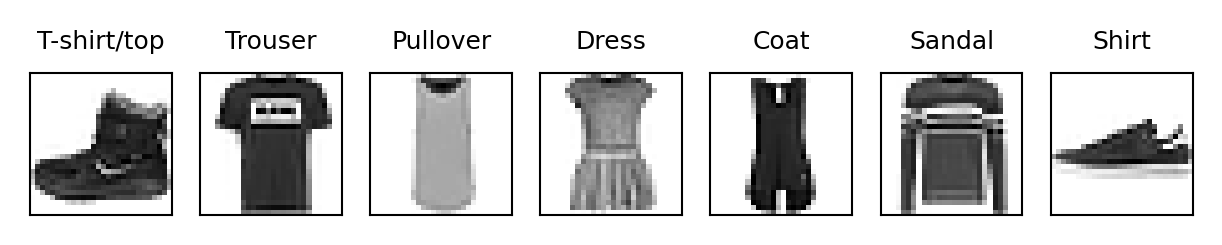

In [55]:
# build a list of figures for plotting
def buildFigureList(fig, subfiglist, titles, length):
    for i in range(0,length):
        pixels = np.array(subfiglist[i], dtype='float')
        pixels = pixels.reshape((28, 28))
        a=fig.add_subplot(1,length,i+1)
        imgplot =plt.imshow(pixels, cmap='gray_r')
        a.set_title(fm_classes[titles[i]], fontsize=6)
        a.axes.get_xaxis().set_visible(False)
        a.axes.get_yaxis().set_visible(False)
    return

subfiglist = []
titles=[]

for i in range(0,7):
    subfiglist.append(X_fm[i])
    titles.append(i)

buildFigureList(plt.figure(1),subfiglist, titles, 7)
plt.show()

Demonstration

In [9]:
def normalize_image(X):
    image = X.reshape((28, 28))
    return (image - np.min(image))/np.ptp(image) # Normalize

image = normalize_image(X_sub[3])
demo2 = convolution_demo(image, all_kernels,
                 vmin=-4, vmax=4, cmap='gray_r');

interactive(children=(Dropdown(description='Kernel:', options=('horizontal', 'diagonal', 'edge_detect'), value…

In [10]:
if not interactive:
    fig, axs = plt.subplots(3, 3, figsize=(5*fig_scale, 5*fig_scale))
    titles = ('Image and kernel', 'Hor. edge filter', 'Filtered image')
    convolution_full(axs[0,:], image, horizontal_edge_kernel, vmin=-4, vmax=4, titles=titles, cmap='gray_r')
    titles = ('Image and kernel', 'Diag. edge filter', 'Filtered image')
    convolution_full(axs[1,:], image, diagonal_edge_kernel, vmin=-4, vmax=4, titles=titles, cmap='gray_r')
    titles = ('Image and kernel', 'Edge detect filter', 'Filtered image')
    convolution_full(axs[2,:], image, edge_detect_kernel, vmin=-4, vmax=4, titles=titles, cmap='gray_r')
    plt.tight_layout()

### Image convolution in practice
* How do we know which filters are best for a given image?
* _Families_ of kernels (or _filter banks_ ) can be run on every image
    * Gabor, Sobel, Haar Wavelets,...
* Gabor filters: Wave patterns generated by changing:
    - Frequency: narrow or wide ondulations
    - Theta: angle (direction) of the wave
    - Sigma: resolution (size of the filter)

Demonstration

interactive(children=(FloatSlider(value=0.46, description='frequency', max=1.0, min=0.01, step=0.05), FloatSli…

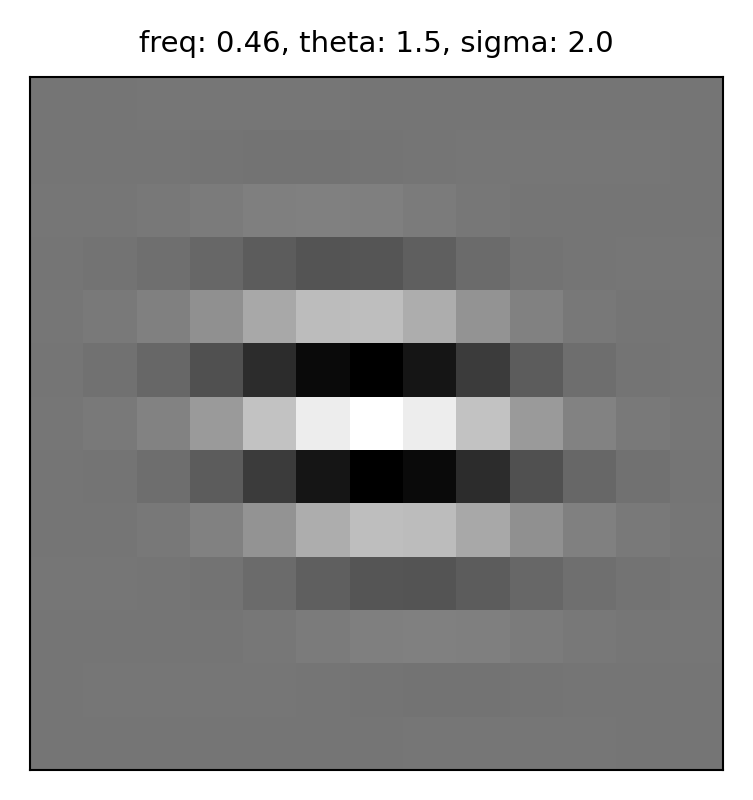

In [40]:
from scipy import ndimage as ndi
from skimage import data
from skimage.util import img_as_float
from skimage.filters import gabor_kernel

# Gabor Filters.
@interact
def demoGabor(frequency=(0.01,1,0.05), theta=(0,3.14,0.1), sigma=(0,5,0.1)):
    plt.gray()
    plt.imshow(np.real(gabor_kernel(frequency=frequency, theta=theta, sigma_x=sigma, sigma_y=sigma)), interpolation='nearest', extent=[-1, 1, -1, 1])
    plt.title(f'freq: {round(frequency,2)}, theta: {round(theta,2)}, sigma: {round(sigma,2)}', fontdict={'fontsize':14*fig_scale})
    plt.xticks([])
    plt.yticks([])

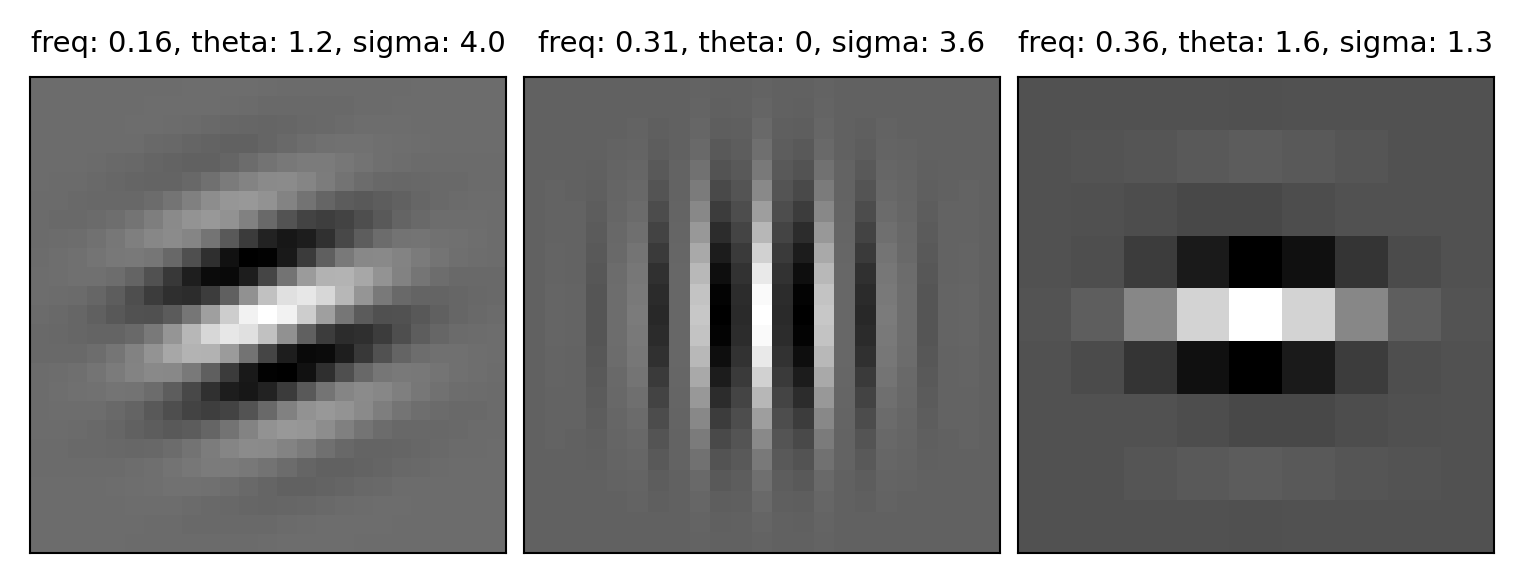

In [41]:
if interactive:
    plt.subplot(1, 3, 1)
    demoGabor(frequency=0.16, theta=1.2, sigma=4.0)
    plt.subplot(1, 3, 2)
    demoGabor(frequency=0.31, theta=0, sigma=3.6)
    plt.subplot(1, 3, 3)
    demoGabor(frequency=0.36, theta=1.6, sigma=1.3)
    plt.tight_layout()

Demonstration on the Fashion-MNIST data

In [44]:
# Calculate the magnitude of the Gabor filter response given a kernel and an imput image
def magnitude(image, kernel):
    image = (image - image.mean()) / image.std() # Normalize images
    return np.sqrt(ndi.convolve(image, np.real(kernel), mode='wrap')**2 +
                   ndi.convolve(image, np.imag(kernel), mode='wrap')**2)

In [46]:
@interact
def demoGabor2(frequency=(0.01,1,0.05), theta=(0,3.14,0.1), sigma=(0,5,0.1)):
    plt.subplot(131)
    plt.title('Original', fontdict={'fontsize':24*fig_scale})
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.subplot(132)
    plt.title('Gabor kernel', fontdict={'fontsize':24*fig_scale})
    plt.imshow(np.real(gabor_kernel(frequency=frequency, theta=theta, sigma_x=sigma, sigma_y=sigma)), interpolation='nearest')
    plt.xticks([])
    plt.yticks([])
    plt.subplot(133)
    plt.title('Response magnitude', fontdict={'fontsize':24*fig_scale})
    plt.imshow(np.real(magnitude(image, gabor_kernel(frequency=frequency, theta=theta, sigma_x=sigma, sigma_y=sigma))), interpolation='nearest')
    plt.tight_layout()
    plt.xticks([])
    plt.yticks([])
    plt.show()

interactive(children=(FloatSlider(value=0.46, description='frequency', max=1.0, min=0.01, step=0.05), FloatSli…

In [48]:
if not interactive:
    demoGabor2(frequency=0.16, theta=1.4, sigma=1.2)

### Filter banks
- Different filters detect different edges, shapes,...
- Not all seem useful

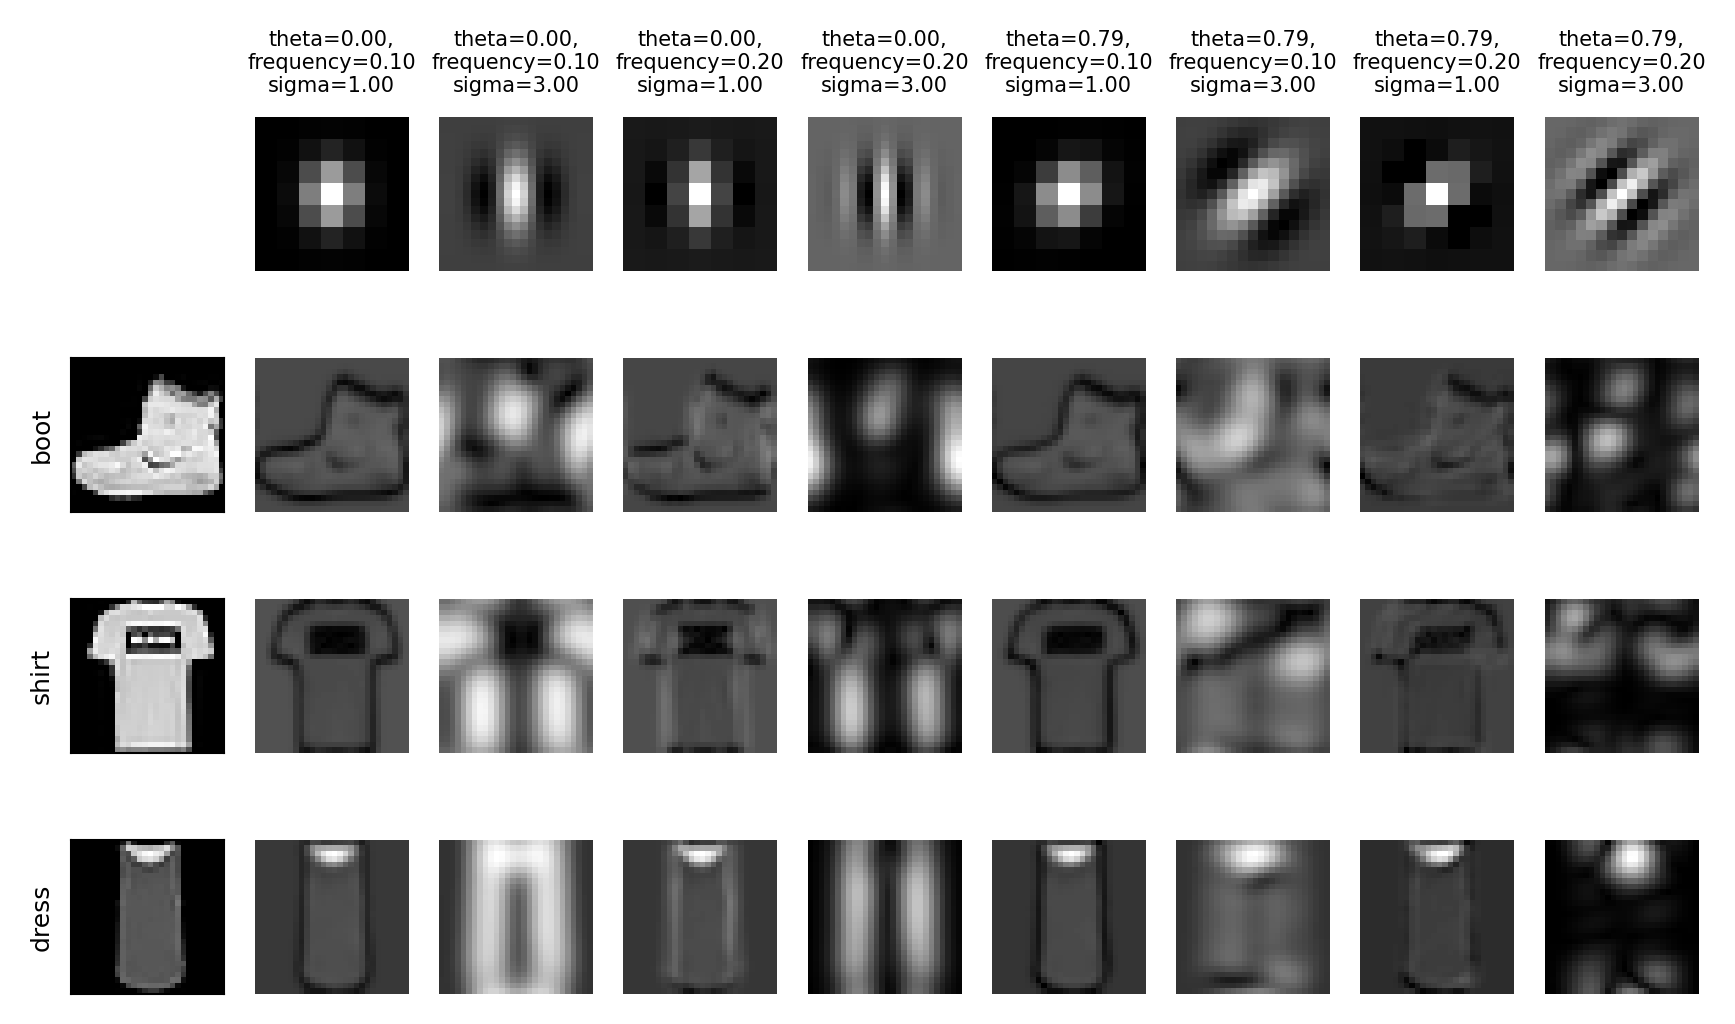

In [50]:
# More images
# Fetch some Fashion-MNIST images
boot = X_fm[0].reshape(28, 28)
shirt = X_fm[1].reshape(28, 28)
dress = X_fm[2].reshape(28, 28)
image_names = ('boot', 'shirt', 'dress')
images = (boot, shirt, dress)

def plot_filter_bank(images):
    # Create a set of kernels, apply them to each image, store the results
    results = []
    kernel_params = []
    for theta in (0, 1):
        theta = theta / 4. * np.pi
        for frequency in (0.1, 0.2):
            for sigma in (1, 3):
                kernel = gabor_kernel(frequency, theta=theta,sigma_x=sigma,sigma_y=sigma)
                params = 'theta=%.2f,\nfrequency=%.2f\nsigma=%.2f' % (theta, frequency, sigma)
                kernel_params.append(params)
                results.append((kernel, [magnitude(img, kernel) for img in images]))

    # Plotting
    fig, axes = plt.subplots(nrows=4, ncols=9, figsize=(14*fig_scale, 8*fig_scale))
    plt.gray()
    #fig.suptitle('Image responses for Gabor filter kernels', fontsize=12)
    axes[0][0].axis('off')

    for label, img, ax in zip(image_names, images, axes[1:]):
        axs = ax[0]
        axs.imshow(img)
        axs.set_ylabel(label, fontsize=12*fig_scale)
        axs.set_xticks([]) # Remove axis ticks 
        axs.set_yticks([])
        
    # Plot Gabor kernel
    col = 1
    for label, (kernel, magnitudes), ax_col in zip(kernel_params, results, axes[0][1:]):
        ax_col.imshow(np.real(kernel), interpolation='nearest') # Plot kernel
        ax_col.set_title(label, fontsize=10*fig_scale)
        ax_col.axis('off')
        
        # Plot Gabor responses with the contrast normalized for each filter
        vmin = np.min(magnitudes)
        vmax = np.max(magnitudes)
        for patch, ax in zip(magnitudes, axes.T[col][1:]):
            ax.imshow(patch, vmin=vmin, vmax=vmax) # Plot convolutions
            ax.axis('off')
        col += 1
    
    plt.show()

plot_filter_bank(images)

## Convolutional neural nets
* Finding relationships between individual pixels and the correct class is hard
* Simplify the problem by decomposing it into smaller problems
* First, discover 'local' patterns (edges, lines, endpoints)
* Representing such local patterns as features makes it easier to learn from them
    * Deeper layers will do that for us
* We could use convolutions, but how to choose the filters?

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_patches.png?raw=1" alt="ml" style="width: 300px;  margin-left: auto; margin-right: auto;"/>

### Convolutional Neural Networks (ConvNets)
* Instead of manually designing the filters, we can also _learn_ them based on data
    * Choose filter sizes (manually), initialize with small random weights
* Forward pass: Convolutional layer slides the filter over the input, generates the output
* Backward pass: Update the filter weights according to the loss gradients
* Illustration for 1 filter: 

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/cnn.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>


### Convolutional layers: Feature maps
* One filter is not sufficient to detect all relevant patterns in an image
* A convolutional layer applies and learns $d$ filters in parallel  
* Slide $d$ filters across the input image (in parallel) -> a (1x1xd) output per patch
* Reassemble into a _feature map_ with $d$ 'channels', a (width x height x d) tensor.

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_convolution.png?raw=1" alt="ml" style="width: 400px;  margin-left: auto; margin-right: auto;"/>

### Border effects (zero padding)
* Consider a 5x5 image and a 3x3 filter: there are only 9 possible locations, hence the output is a 3x3 feature map
* If we want to maintain the image size, we use _zero-padding_, adding 0's all around the input tensor.

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_padding.png?raw=1" alt="ml" style="float: left; width: 45%;"/>
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_padding_2.png?raw=1" alt="ml" style="float: left; width: 45%;"/>

### Undersampling (striding)
* Sometimes, we want to _downsample_ a high-resolution image
    * Faster processing, less noisy (hence less overfitting)
    * Forces the model to summarize information in (smaller) feature maps
* One approach is to _skip_ values during the convolution
    * Distance between 2 windows: _stride length_
* Example with stride length 2 (without padding):
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_strides.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>

### Max-pooling
* Another approach to shrink the input tensors is _max-pooling_ :
    - Run a filter with a fixed stride length over the image
        - Usually 2x2 filters and stride lenght 2
    - The filter simply returns the _max_ (or _avg_ ) of all values
* Agressively reduces the number of weights (less overfitting)

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/maxpool.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>

### Receptive field

* With 3x3 convolutions, each output neuron is influenced by 3x3 nodes in the first layer, 5x5 nodes in the layer before that, etc.
* _Receptive field_: how much each output neuron 'sees' of the input image
* Maxpooling increases the receptive field, meaning networks can be less deep
    * Also: larger filters, striding, dilation, ...
* Increases _translation invariance_ : patterns can affect the predictions no matter where they occur in the image


<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/receptive_field.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>

### Dilated convolutions
* Downsample by introducing 'gaps' between filter elements by spacing them out 
* Increases the receptive field exponentially
* Doesn't need extra parameters or computation (unlike larger filters)
* Retains feature map size (unlike pooling) 
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/dilation.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>

## Convolutional nets in practice
* Use multiple convolutional layers to learn patterns at different levels of abstraction
    * Find local patterns first (e.g. edges), then patterns across those patterns
* Use MaxPooling layers to reduce resolution, increase translation invariance
* Use sufficient filters in the first layer (otherwise information gets lost)
* In deeper layers, use increasingly more filters
    * Preserve information about the input as resolution descreases
    * Avoid decreasing the number of activations (resolution x nr of filters)
* For very deep nets, add _skip connections_ to preserve information (and gradients)
    * Sums up outputs of earlier layers to those of later layers (with same dimensions)

### Example with PyTorch
    
* `Conv2d` for 2D convolutional layers
    - Grayscale image: 1 _in_channels_
    - 32 filters: 32 _out_channels_, 3x3 size
    - Deeper layers use 64 filters
    - `ReLU` activation, no padding
    - `MaxPool2d` for max-pooling, 2x2
        
``` python
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3),
    nn.ReLU()
)
```

In [59]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0),
    nn.ReLU(), 
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU()
)

In [ ]:
### Old, remove
from tensorflow.keras import layers
from tensorflow.keras import models
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

* Observe how the input image on 1x28x28 is transformed to a 64x3x3 feature map 
    * In pytorch, shapes are (batch_size, channels, height, width)
* Conv2d parameters = (kernel size^2 × input channels + 1) × output channels
* No zero-padding: every output is 2 pixels less in every dimension
* After every MaxPooling, resolution halved in every dimension

In [60]:
from torchinfo import summary
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 64, 3, 3]             --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─ReLU: 1-5                              [1, 64, 11, 11]           --
├─MaxPool2d: 1-6                         [1, 64, 5, 5]             --
├─Conv2d: 1-7                            [1, 64, 3, 3]             36,928
├─ReLU: 1-8                              [1, 64, 3, 3]             --
Total params: 55,744
Trainable params: 55,744
Non-trainable params: 0
Total mult-adds (M): 2.79
Input size (MB): 0.00
Forward/backward pass size (MB): 0.24
Params size (MB): 0.22
Estimated Total Size (MB): 0.47

* To classify the images, we still need a linear and output layer.
* We flatten the 3x3x64 feature map to a vector of size 576

``` python
model = nn.Sequential(
    ...
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(64 * 3 * 3, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)
```

In [62]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(64 * 3 * 3, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

Complete model. Flattening adds a lot of weights!

In [63]:
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─ReLU: 1-5                              [1, 64, 11, 11]           --
├─MaxPool2d: 1-6                         [1, 64, 5, 5]             --
├─Conv2d: 1-7                            [1, 64, 3, 3]             36,928
├─ReLU: 1-8                              [1, 64, 3, 3]             --
├─Flatten: 1-9                           [1, 576]                  --
├─Linear: 1-10                           [1, 64]                   36,928
├─ReLU: 1-11                             [1, 64]                   --
├─Linear: 1-12                           [1, 10]                   650
T

### Global Average Pooling (GAP)
* Instead of flattening, we do GAP: returns average of each activation map
* We can drop the hidden dense layer: number of outputs > number of classes

``` python
model = nn.Sequential(...
    nn.AdaptiveAvgPool2d(1), # Global Average Pooling
    nn.Flatten(),            # Convert (batch, 64, 1, 1) -> (batch, 64)
    nn.Linear(64, 10))       # Output layer for 10 classes
```

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/09_GAP.png?raw=1" alt="ml" style="width: 70%;  margin-left: auto; margin-right: auto;"/>



* With `GlobalAveragePooling`: much fewer weights to learn
* Use with caution: this destroys the location information learned by the CNN
* Not ideal for tasks such as object localization

In [67]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=0),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),  # Global Average Pooling (GAP)
    nn.Flatten(),  # Convert (batch, 64, 1, 1) -> (batch, 64)
    nn.Linear(64, 10)  # Output layer for 10 classes
)
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─ReLU: 1-5                              [1, 64, 11, 11]           --
├─MaxPool2d: 1-6                         [1, 64, 5, 5]             --
├─Conv2d: 1-7                            [1, 64, 3, 3]             36,928
├─ReLU: 1-8                              [1, 64, 3, 3]             --
├─AdaptiveAvgPool2d: 1-9                 [1, 64, 1, 1]             --
├─Flatten: 1-10                          [1, 64]                   --
├─Linear: 1-11                           [1, 10]                   650
Total params: 56,394
Trainable params: 56,394
Non-trainable params: 0
Total

Run the model on MNIST dataset
* Train and test as usual: 99% accuracy
    * Compared to 97,8% accuracy with the dense architecture
    * `Flatten` and `GlobalAveragePooling` yield similar performance

In [116]:
# Keeps a history of scores to make plotting easier
class MetricTracker(pl.Callback):
    def __init__(self):
        super().__init__()
        self.history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": []
        }
        self.first_validation = True  # Flag to ignore first validation step

    def on_train_epoch_end(self, trainer, pl_module):
        """Collects training metrics at the end of each epoch"""
        train_loss = trainer.callback_metrics.get("train_loss")
        train_acc = trainer.callback_metrics.get("train_acc")

        if train_loss is not None:
            self.history["train_loss"].append(train_loss.cpu().item())
        if train_acc is not None:
            self.history["train_acc"].append(train_acc.cpu().item())

    def on_validation_epoch_end(self, trainer, pl_module):
        """Collects validation metrics at the end of each epoch"""
        if self.first_validation:  
            self.first_validation = False  # Skip first validation logging
            return  

        val_loss = trainer.callback_metrics.get("val_loss")
        val_acc = trainer.callback_metrics.get("val_acc")

        if val_loss is not None:
            self.history["val_loss"].append(val_loss.cpu().item())
        if val_acc is not None:
            self.history["val_acc"].append(val_acc.cpu().item())
            
def plot_training(history):
    plt.figure(figsize=(12, 4))  # Increased figure size

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss", marker='o', lw=2)
    plt.plot(history["val_loss"], label="Validation Loss", marker='o', lw=2)
    plt.xlabel("Epochs", fontsize=14)  # Larger font size
    plt.ylabel("Loss", fontsize=14)
    plt.title("Loss vs. Epochs", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Accuracy", marker='o', lw=2)
    plt.plot(history["val_acc"], label="Validation Accuracy", marker='o', lw=2)
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Accuracy", fontsize=14)
    plt.title("Accuracy vs. Epochs", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)

    plt.tight_layout()  # Adjust layout for readability
    plt.show()

In [115]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split
from torchmetrics.functional import accuracy

# Model in Pytorch Lightning
class MNISTModel(pl.LightningModule):
    def __init__(self, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 10)
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    # Logging of loss and accuracy for later plotting
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = accuracy(logits, y, task="multiclass", num_classes=10)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        self.log("train_acc", acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = accuracy(logits, y, task="multiclass", num_classes=10)
        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

# Compute mean and std to normalize the data
# Couldn't find a way to do this automatically in PyTorch :(
# Normalization is not strictly needed, but speeds up convergence
dataset = datasets.MNIST(root=".", train=True, transform=transforms.ToTensor(), download=True)
loader = torch.utils.data.DataLoader(dataset, batch_size=1000, num_workers=4, shuffle=False)
mean = torch.mean(torch.stack([batch[0].mean() for batch in loader]))
std = torch.mean(torch.stack([batch[0].std() for batch in loader]))

# Loading the data. We'll discuss data loaders again soon.
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, batch_size=64):
        super().__init__()
        self.batch_size = batch_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((mean,), (std,))  # Normalize MNIST. Make more general?
        ])

    def prepare_data(self):
        datasets.MNIST(root=".", train=True, download=True)  # Downloads dataset

    def setup(self, stage=None):
        full_train = datasets.MNIST(root=".", train=True, transform=self.transform)
        self.train, self.val = random_split(full_train, [55000, 5000])
        self.test = datasets.MNIST(root=".", train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val, batch_size=self.batch_size, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test, batch_size=self.batch_size, num_workers=4)

    
# Initialize data & model
pl.seed_everything(42)  # Ensure reproducibility
data_module = MNISTDataModule(batch_size=64)
model = MNISTModel(learning_rate=0.001)

# Trainer with logging & checkpointing
accelerator = "cpu"
if torch.backends.mps.is_available():
    accelerator = "mps"
if torch.cuda.is_available():
    accelerator = "gpu"

metric_tracker = MetricTracker()  # Callback to track per-epoch metrics

trainer = pl.Trainer(
    max_epochs=10,  # Train for 10 epochs
    accelerator=accelerator,
    devices="auto",
    log_every_n_steps=10,
    deterministic=True,
    callbacks=[metric_tracker]  # Attach callback to trainer
)

trainer.fit(model, datamodule=data_module)

history = metric_tracker.history

# Test after training (sanity check)
# trainer.test(model, datamodule=data_module)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | Sequential       | 56.4 K | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
56.4 K    Trainable params
0         Non-trainable params
56.4 K    Total params
0.226     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=10` reached.


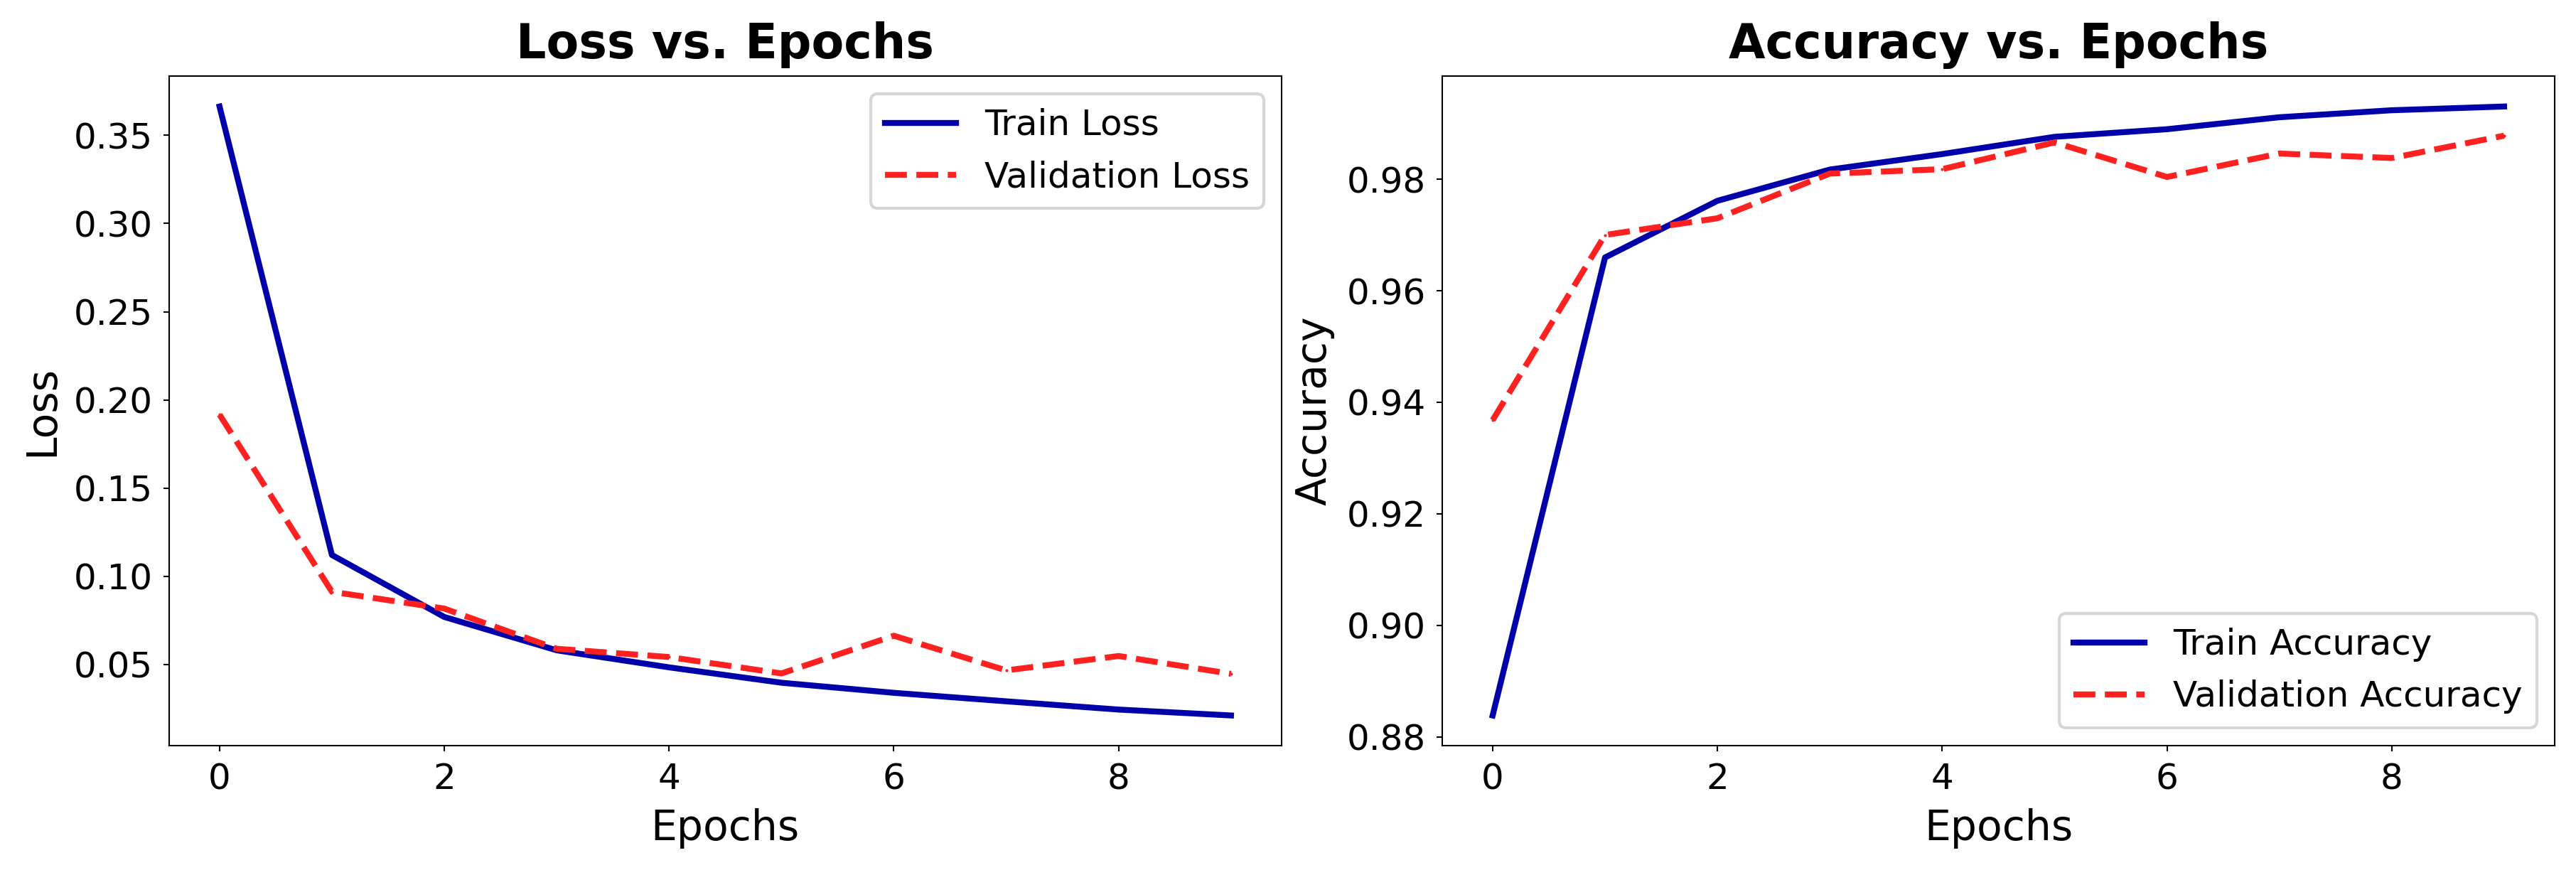

In [117]:
plot_training(history)

## Cats vs Dogs
* A more realistic dataset: [Cats vs Dogs](https://www.kaggle.com/c/dogs-vs-cats/data)
    - Colored JPEG images, different sizes
    - Not nicely centered, translation invariance is important
* Preprocessing
    - Decode JPEG images to floating-point tensors
    - Rescale pixel values to [0,1]
    - Resize images to 150x150 pixels

Uncomment to run from scratch

```python
# TODO: upload dataset to OpenML so we can avoid the manual steps.

import os, shutil 
# Download data from https://www.kaggle.com/c/dogs-vs-cats/data
# Uncompress `train.zip` into the `original_dataset_dir`
original_dataset_dir = '../data/cats-vs-dogs_original'

# The directory where we will
# store our smaller dataset
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')

if not os.path.exists(data_dir):
    os.mkdir(data_dir)
    os.mkdir(train_dir)
    os.mkdir(validation_dir)
    
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

if not os.path.exists(train_cats_dir):
    os.mkdir(train_cats_dir)
    os.mkdir(train_dogs_dir)
    os.mkdir(validation_cats_dir)
    os.mkdir(validation_dogs_dir)

# Copy first 2000 cat images to train_cats_dir
fnames = ['cat.{}.jpg'.format(i) for i in range(2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_cats_dir, fname)
    shutil.copyfile(src, dst)
    
# Copy next 1000 cat images to validation_cats_dir
fnames = ['cat.{}.jpg'.format(i) for i in range(2000, 3000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_cats_dir, fname)
    shutil.copyfile(src, dst)
    
# Copy first 2000 dog images to train_dogs_dir
fnames = ['dog.{}.jpg'.format(i) for i in range(2000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(train_dogs_dir, fname)
    shutil.copyfile(src, dst)
    
# Copy next 1000 dog images to validation_dogs_dir
fnames = ['dog.{}.jpg'.format(i) for i in range(2000, 3000)]
for fname in fnames:
    src = os.path.join(original_dataset_dir, fname)
    dst = os.path.join(validation_dogs_dir, fname)
    shutil.copyfile(src, dst)
```

In [108]:
import random

# Set random seed for reproducibility
def seed_everything(seed=42):
    pl.seed_everything(seed)  # Sets seed for PyTorch Lightning
    torch.manual_seed(seed)  # PyTorch
    torch.cuda.manual_seed_all(seed)  # CUDA (if available)
    np.random.seed(seed)  # NumPy
    random.seed(seed)  # Python random module
    torch.backends.cudnn.deterministic = True  # Ensures reproducibility in CNNs
    torch.backends.cudnn.benchmark = False  # Ensures consistency

seed_everything(42)  # Set global seed

class CatDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=20, img_size=(150, 150)):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size

        # Define image transformations
        self.transform = transforms.Compose([
            transforms.Resize(self.img_size),  # Resize to 150x150
            transforms.ToTensor(),  # Convert to tensor (also scales 0-1)
        ])

    def setup(self, stage=None):
        """Load datasets"""
        train_dir = os.path.join(self.data_dir, "train")
        val_dir = os.path.join(self.data_dir, "validation")

        self.train_dataset = datasets.ImageFolder(root=train_dir, transform=self.transform)
        self.val_dataset = datasets.ImageFolder(root=val_dir, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

# ----------------------------
# Load dataset and visualize a batch
# ----------------------------
data_module = CatDataModule(data_dir=data_dir)
data_module.setup()
train_loader = data_module.train_dataloader()

Seed set to 42


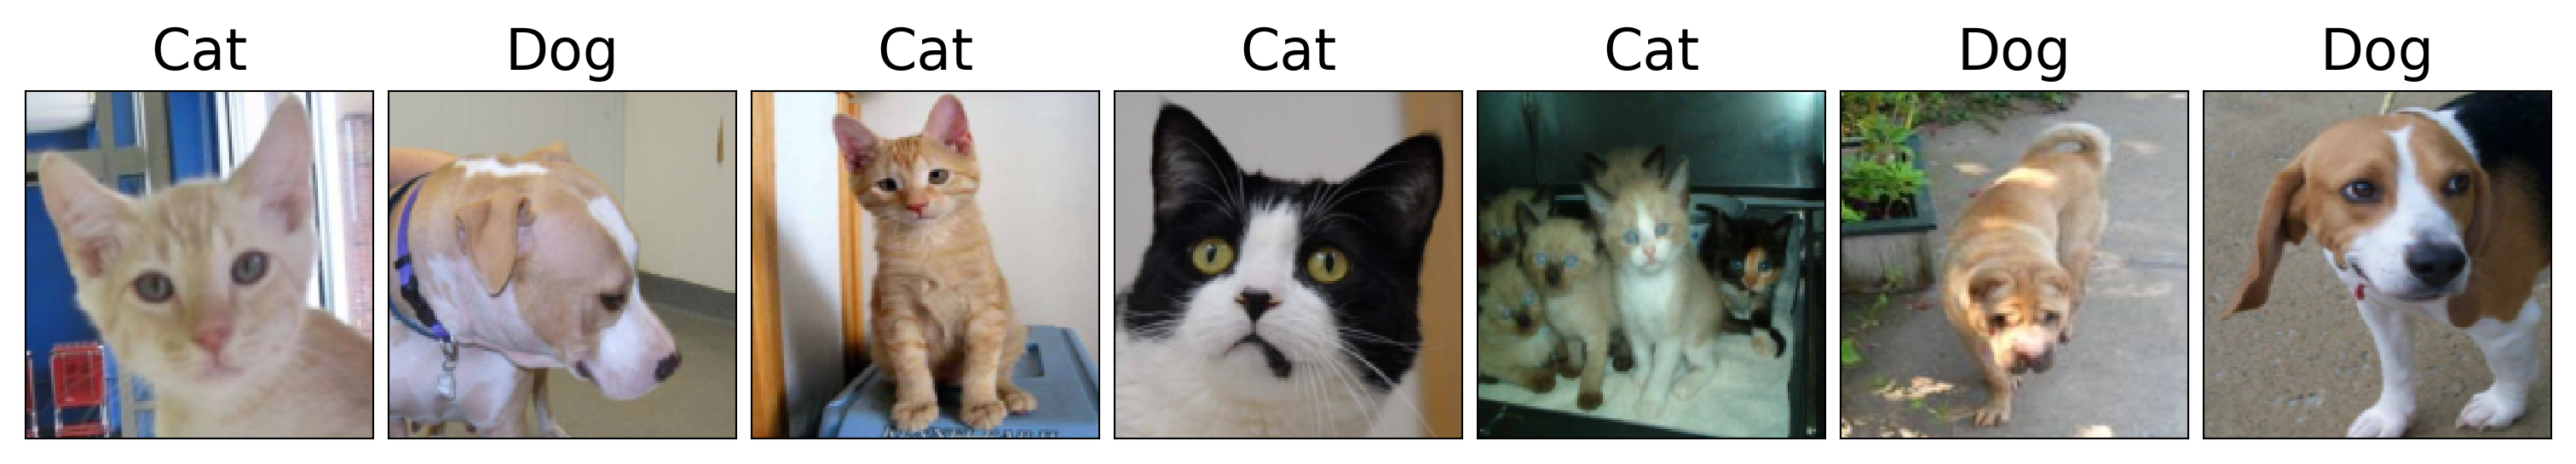

In [109]:
# Get a batch of data
data_batch, labels_batch = next(iter(train_loader))

# Visualize images
plt.figure(figsize=(10, 5))
for i in range(7):
    plt.subplot(1, 7, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(data_batch[i].permute(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
    plt.title("Cat" if labels_batch[i] == 0 else "Dog", fontsize=16)
plt.tight_layout()
plt.show()

### Data loader
* We create a Pytorch Lightning `DataModule` to do preprocessing and data loading

``` python
class ImageDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=20, img_size=(150, 150)):
        super().__init__()
        self.transform = transforms.Compose([
            transforms.Resize(self.img_size),  # Resize to 150x150
            transforms.ToTensor()])  # Convert to tensor (also scales 0-1)
    def setup(self, stage=None):
        self.train_dataset = datasets.ImageFolder(root=train_dir, transform=self.transform)
        self.val_dataset = datasets.ImageFolder(root=val_dir, transform=self.transform)
```
``` python
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)
```

In [110]:
from torchmetrics.classification import BinaryAccuracy

# Model in PyTorch Lightning
class CatImageClassifier(pl.LightningModule):
    def __init__(self, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        # Define convolutional layers
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 128, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d(1)  # GAP replaces Flatten()
        )

        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 512),  # GAP outputs (batch, 128, 1, 1) → Flatten to (batch, 128)
            nn.ReLU(),
            nn.Linear(512, 1)  # Binary classification (1 output neuron)
        )

        self.loss_fn = nn.BCEWithLogitsLoss()
        self.accuracy = BinaryAccuracy()

    def forward(self, x):
        x = self.conv_layers(x)  # Convolutions + GAP
        x = x.view(x.size(0), -1)  # Flatten from (batch, 128, 1, 1) → (batch, 128)
        x = self.fc_layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(1)  # Remove extra dimension
        loss = self.loss_fn(logits, y.float())  # BCE loss requires float labels

        preds = torch.sigmoid(logits)  # Convert logits to probabilities
        acc = self.accuracy(preds, y)

        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        self.log("train_acc", acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(1)
        loss = self.loss_fn(logits, y.float())

        preds = torch.sigmoid(logits)
        acc = self.accuracy(preds, y)

        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

###  Model
Since the images are more complex, we add another convolutional layer and increase the number of filters to 128.

In [111]:
model = CatImageClassifier()
summary(model, input_size=(1, 3, 150, 150))

Layer (type:depth-idx)                   Output Shape              Param #
CatImageClassifier                       [1, 1]                    --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 32, 148, 148]         896
│    └─ReLU: 2-2                         [1, 32, 148, 148]         --
│    └─MaxPool2d: 2-3                    [1, 32, 74, 74]           --
│    └─Conv2d: 2-4                       [1, 64, 72, 72]           18,496
│    └─ReLU: 2-5                         [1, 64, 72, 72]           --
│    └─MaxPool2d: 2-6                    [1, 64, 36, 36]           --
│    └─Conv2d: 2-7                       [1, 128, 34, 34]          73,856
│    └─ReLU: 2-8                         [1, 128, 34, 34]          --
│    └─MaxPool2d: 2-9                    [1, 128, 17, 17]          --
│    └─Conv2d: 2-10                      [1, 128, 15, 15]          147,584
│    └─ReLU: 2-11                        [1, 128, 15, 15]          --
│

### Training
* We use a `Trainer` module (from PyTorch Lightning) to simplify training
    
``` python
trainer = pl.Trainer(
    max_epochs=20,        # Train for 20 epochs
    accelerator="gpu",    # Move data and model to GPU
    devices="auto",       # Number of GPUs
    deterministic=True,   # Set random seeds, for reproducibility
    callbacks=[metric_tracker]  # Callback for plotting later
)
trainer.fit(model, datamodule=data_module)
```

The model learns well for the first 30 epochs, but then starts overfitting

In [122]:
# Train Cat model
pl.seed_everything(42)  # Ensure reproducibility
data_module = CatDataModule(data_dir, batch_size=64)
model = CatImageClassifier(learning_rate=0.001)
metric_tracker = MetricTracker()  # Callback to track per-epoch metrics

trainer = pl.Trainer(
    max_epochs=30,  # Train for 20 epochs
    accelerator=accelerator,
    devices="auto",
    log_every_n_steps=10,
    deterministic=True,
    callbacks=[metric_tracker]  # Attach callback to trainer
)

trainer.fit(model, datamodule=data_module)

history_cat = metric_tracker.history

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | conv_layers | Sequential        | 240 K  | train
1 | fc_layers   | Sequential        | 66.6 K | train
2 | loss_fn     | BCEWithLogitsLoss | 0      | train
3 | accuracy    | BinaryAccuracy    | 0      | train
----------------------------------------------------------
307 K     Trainable params
0         Non-trainable params
307 K     Total params
1.230     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=30` reached.


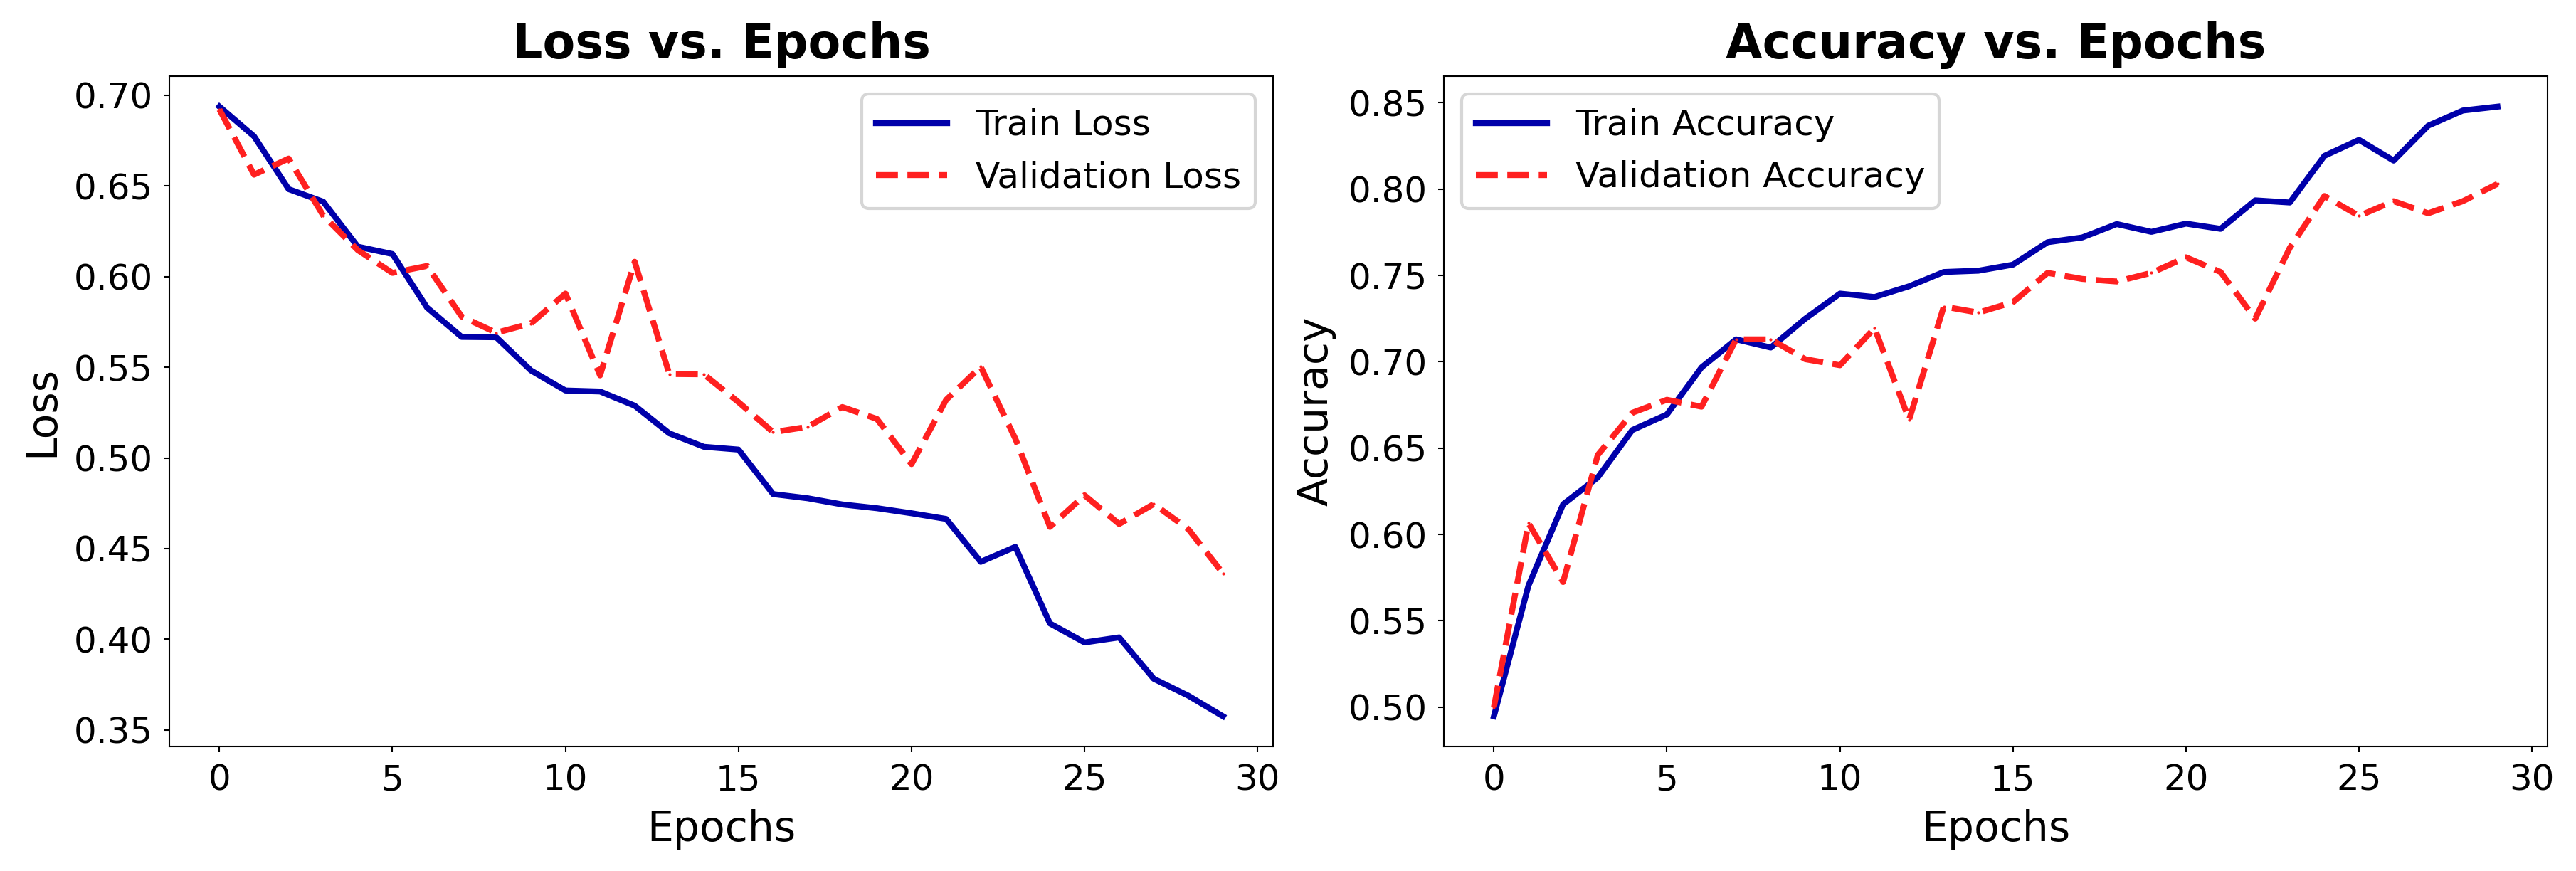

In [123]:
plot_training(history_cat)

* Various ways to further improve the model:
    - Generating more training data (data augmentation)
    - Regularization (e.g. Dropout, L1/L2, Batch Normalization,...)
    - Use pretrained rather than randomly initialized filters

### Data augmentation
* Generate new images via image transformations (only on training data!)
    - Images will be randomly transformed _every epoch_
* Update the transform in the data module

``` python
self.train_transform = transforms.Compose([
    transforms.Resize(self.img_size), # Resize to 150x150
    transforms.RandomRotation(40),    # Rotations up to 40 degrees
    transforms.RandomResizedCrop(self.img_size, 
                                 scale=(0.8, 1.2)), # Scale + crop, up to 20%
    transforms.RandomHorizontalFlip(),              # Horizontal flip
    transforms.RandomAffine(degrees=0, shear=20),   # Shear, up to 20%
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                           saturation=0.2),         # Color jitter
```
``` python
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
```

In [125]:
class CatDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=20, img_size=(150, 150)):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size

        # Training Data Augmentation 
        self.train_transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.RandomRotation(40),
            transforms.RandomResizedCrop(self.img_size, scale=(0.8, 1.2)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomAffine(degrees=0, shear=20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        # Test Data Transforms (NO augmentation, just resize + normalize)
        self.val_transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def setup(self, stage=None):
        """Load datasets with correct transforms"""
        train_dir = os.path.join(self.data_dir, "train")
        val_dir = os.path.join(self.data_dir, "validation")

        # Apply augmentation only to training data
        self.train_dataset = datasets.ImageFolder(root=train_dir, transform=self.train_transform)
        self.val_dataset = datasets.ImageFolder(root=val_dir, transform=self.val_transform)

    def train_dataloader(self):
        """Applies augmentation via the pre-defined transform"""
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        """Loads validation data WITHOUT augmentation"""
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=4)

Augmentation example

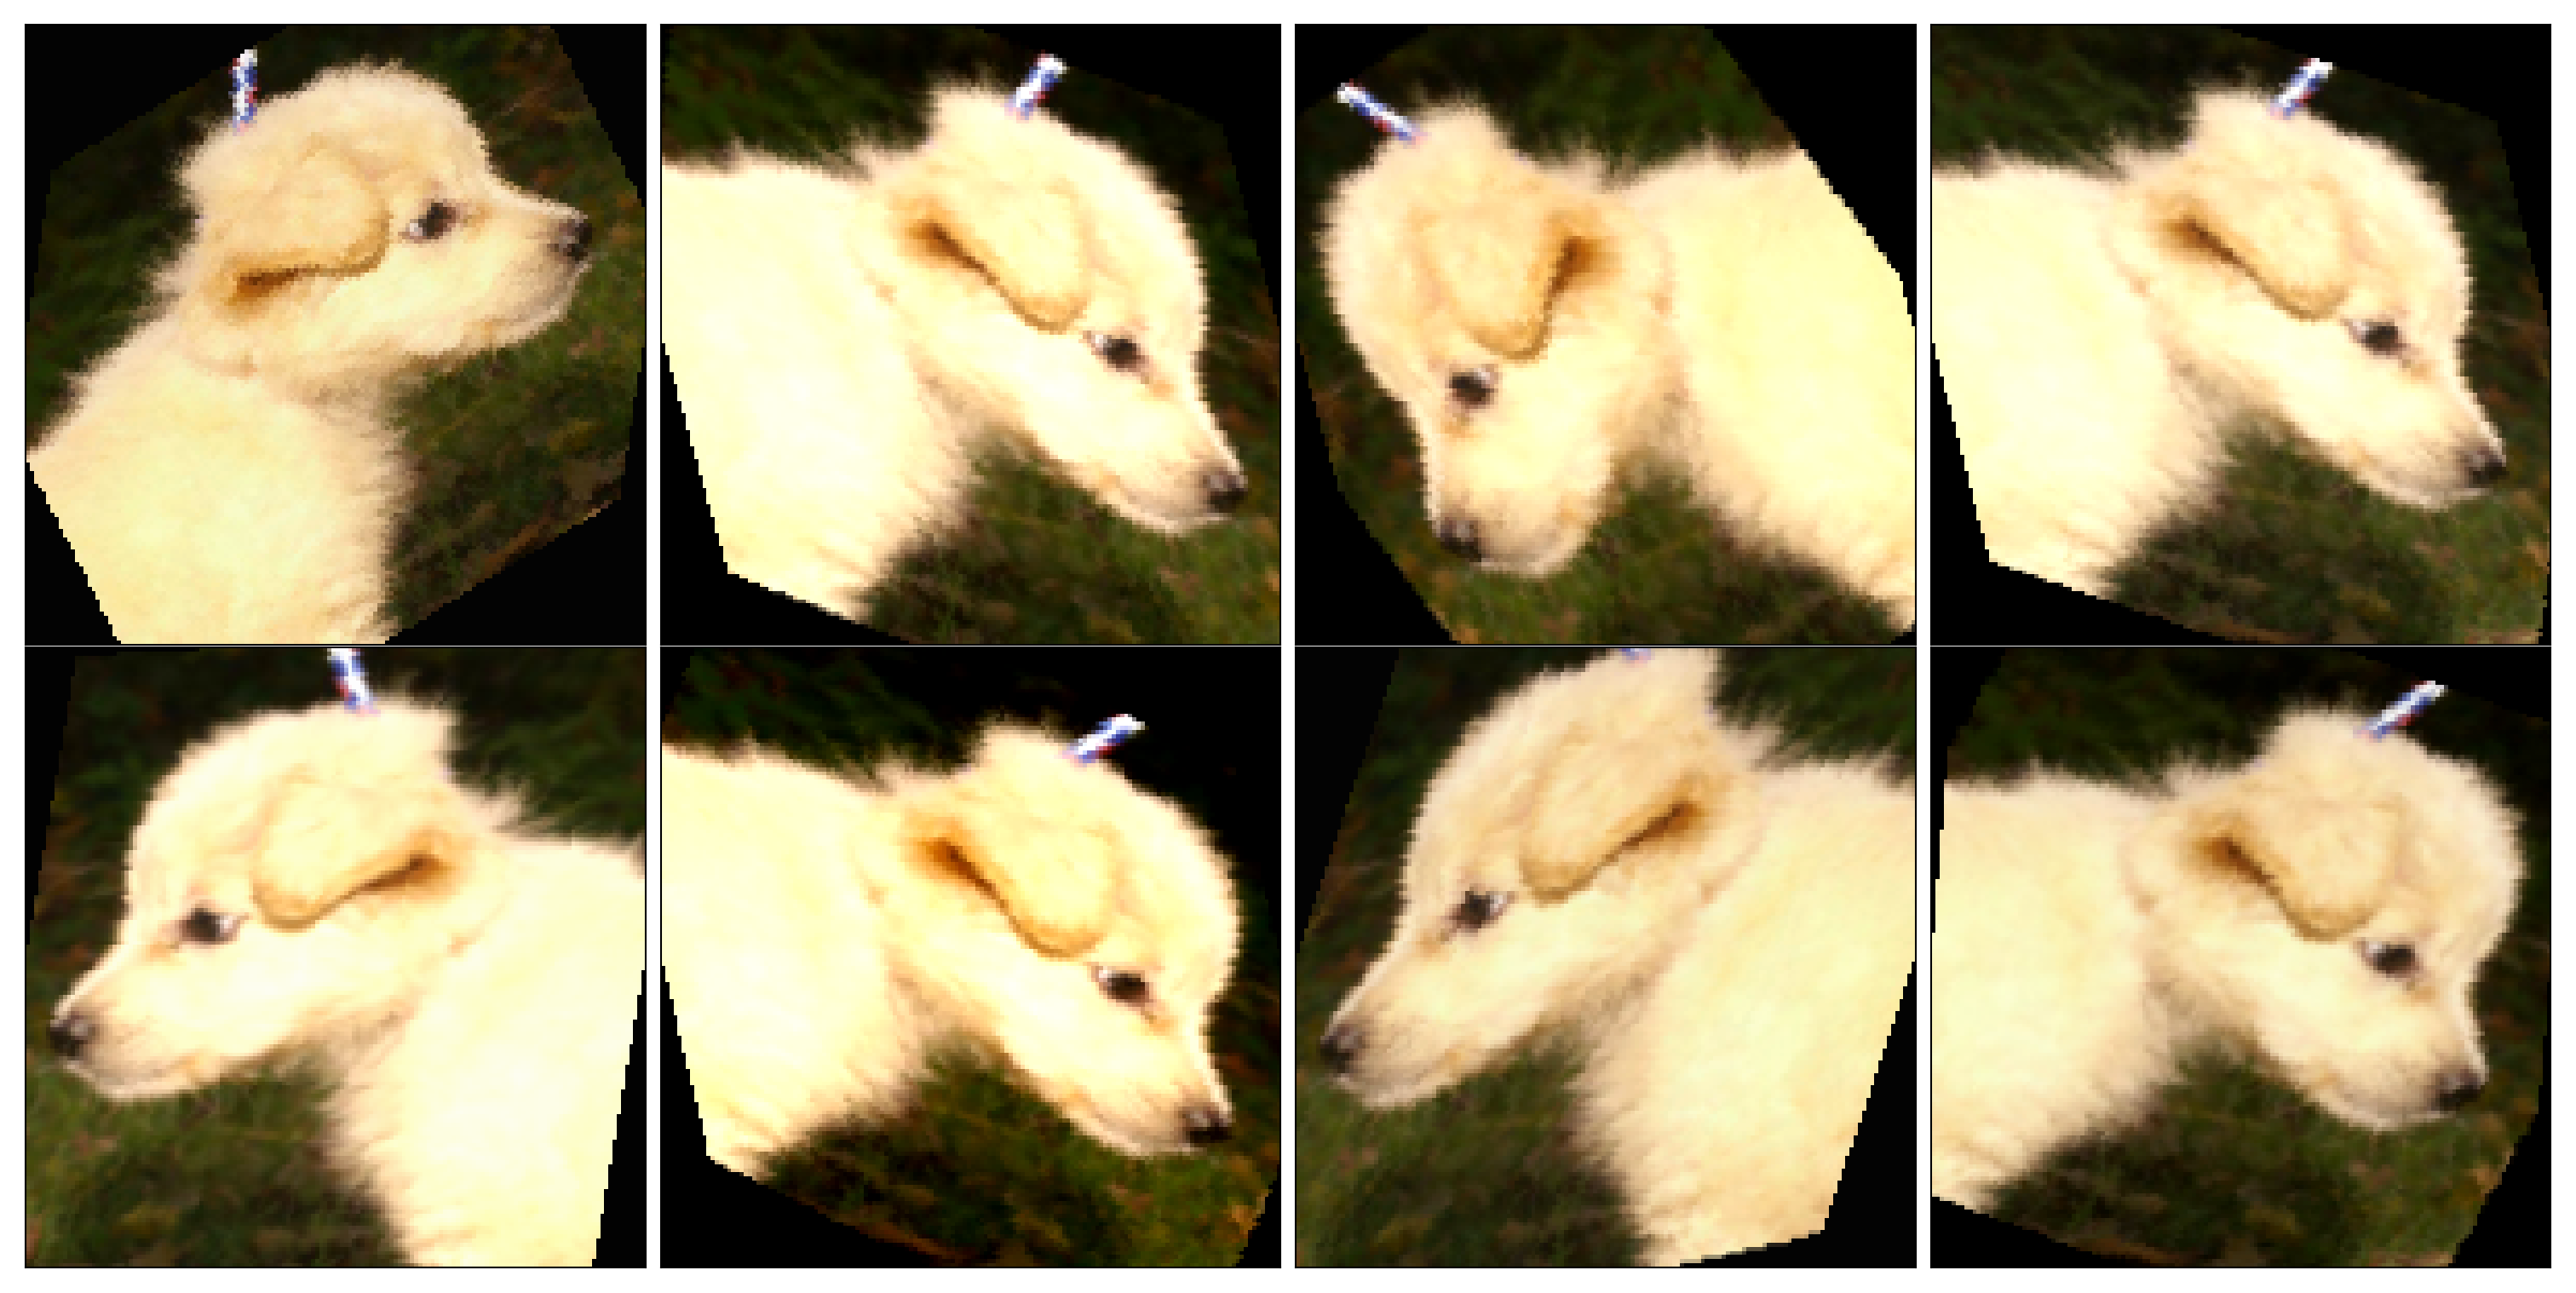

In [147]:
def show_augmented_images(data_module, num_images=8):
    """Visualize the same image with different random augmentations."""
    
    train_dataset = data_module.train_dataset  # Get training dataset with augmentation
    
    # Select a random image (without augmentation)
    idx = np.random.randint(len(train_dataset))
    original_img, label = train_dataset[idx]  # This is already augmented

    # Convert original image back to NumPy format
    original_img_np = original_img.permute(1, 2, 0).numpy()  # Convert (C, H, W) → (H, W, C)
    original_img_np = (original_img_np - original_img_np.min()) / (original_img_np.max() - original_img_np.min())  # Normalize

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))  # Create 4x2 grid
    axes = axes.flatten()

    for i in range(num_images):
        # Apply new augmentation on the same image each time
        img, _ = train_dataset[idx]  # Re-fetch the same image, but with a new random augmentation
        
        # Convert tensor image back to NumPy format
        img = img.permute(1, 2, 0).numpy()  # Convert (C, H, W) → (H, W, C)
        img = (img - img.min()) / (img.max() - img.min())  # Normalize

        # Plot the augmented image
        axes[i].imshow(img)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

    plt.tight_layout()
    plt.show()

# ----------------------------
# Load dataset and visualize augmented images
# ----------------------------
data_module = CatDataModule(data_dir)  # Set correct dataset path
data_module.setup()
show_augmented_images(data_module)

We also add Dropout before the Dense layer

In [148]:
class CatImageClassifier(pl.LightningModule):
    def __init__(self, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        # Define convolutional layers (CNN)
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 128, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d(1)  # GAP instead of Flatten
        )

        # Fully connected layers (FC) with Dropout
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 512),  # GAP outputs (batch, 128, 1, 1) → Flatten to (batch, 128)
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout (same as Keras Dropout(0.5))
            nn.Linear(512, 1)  # Binary classification (1 output neuron)
        )

        self.loss_fn = nn.BCEWithLogitsLoss()
        self.accuracy = BinaryAccuracy()

    def forward(self, x):
        x = self.conv_layers(x)  # Convolutions + GAP
        x = x.view(x.size(0), -1)  # Flatten from (batch, 128, 1, 1) → (batch, 128)
        x = self.fc_layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(1)  # Remove extra dimension
        loss = self.loss_fn(logits, y.float())  # BCE loss requires float labels

        preds = torch.sigmoid(logits)  # Convert logits to probabilities
        acc = self.accuracy(preds, y)

        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        self.log("train_acc", acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze(1)
        loss = self.loss_fn(logits, y.float())

        preds = torch.sigmoid(logits)
        acc = self.accuracy(preds, y)

        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
    
model = CatImageClassifier()
summary(model, input_size=(1, 3, 150, 150))

Layer (type:depth-idx)                   Output Shape              Param #
CatImageClassifier                       [1, 1]                    --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 32, 148, 148]         896
│    └─ReLU: 2-2                         [1, 32, 148, 148]         --
│    └─MaxPool2d: 2-3                    [1, 32, 74, 74]           --
│    └─Conv2d: 2-4                       [1, 64, 72, 72]           18,496
│    └─ReLU: 2-5                         [1, 64, 72, 72]           --
│    └─MaxPool2d: 2-6                    [1, 64, 36, 36]           --
│    └─Conv2d: 2-7                       [1, 128, 34, 34]          73,856
│    └─ReLU: 2-8                         [1, 128, 34, 34]          --
│    └─MaxPool2d: 2-9                    [1, 128, 17, 17]          --
│    └─Conv2d: 2-10                      [1, 128, 15, 15]          147,584
│    └─ReLU: 2-11                        [1, 128, 15, 15]          --
│

(Almost) no more overfitting!

In [ ]:
pl.seed_everything(42)  # Ensure reproducibility
data_module = CatDataModule(data_dir, batch_size=64)
model = CatImageClassifier(learning_rate=0.001)
metric_tracker = MetricTracker()  # Callback to track per-epoch metrics

trainer = pl.Trainer(
    max_epochs=10,  # Train for 20 epochs
    accelerator=accelerator,
    devices="auto",
    log_every_n_steps=10,
    deterministic=True,
    callbacks=[metric_tracker]  # Attach callback to trainer
)

trainer.fit(model, datamodule=data_module)
history_cat2 = metric_tracker.history

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | conv_layers | Sequential        | 240 K  | train
1 | fc_layers   | Sequential        | 66.6 K | train
2 | loss_fn     | BCEWithLogitsLoss | 0      | train
3 | accuracy    | BinaryAccuracy    | 0      | train
----------------------------------------------------------
307 K     Trainable params
0         Non-trainable params
307 K     Total params
1.230     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

In [ ]:
plot_training(history_cat2)

## Real-world CNNs
### VGG16
* Deeper architecture (16 layers): allows it to learn more complex high-level features
    * Textures, patterns, shapes,...
* Small filters (3x3) work better: capture spatial information while reducing number of parameters
* Max-pooling (2x2): reduces spatial dimension, improves translation invariance
    * Lower resolution forces model to learn robust features (less sensitive to small input changes)
    * Only after every 2 layers, otherwise dimensions reduce too fast
* Downside: too many parameters, expensive to train
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/09_vgg16.png?raw=1" alt="ml" style="width: 70%;  margin-left: auto; margin-right: auto;"/>

### Inceptionv3
* Inception modules: parallel branches learn features of different sizes and scales (3x3, 5x5, 7x7,...)
    * Add reduction blocks that reduce dimensionality via convolutions with stride 2
* Factorized convolutions: a 3x3 conv. can be replaced by combining 1x3 and 3x1, and is 33% cheaper
    * A 5x5 can be replaced by combining 3x3 and 3x3, which can in turn be factorized as above
* 1x1 convolutions, or Network-In-Network (NIN) layers help reduce the number of channels: cheaper
* An auxiliary classifier adds an additional gradient signal deeper in the network
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/09_inception.png?raw=1" alt="ml" style="width: 80%;  margin-left: auto; margin-right: auto;"/>

#### Factorized convolutions
* A 3x3 conv. can be replaced by combining 1x3 and 3x1, and is 33% cheaper
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/factorized_convolutions.jpg?raw=1" alt="ml" style="width: 80%;  margin-left: auto; margin-right: auto;"/>

### ResNet50
* Residual (skip) connections: add earlier feature map to a later one (dimensions must match)
    * Information can bypass layers, reduces vanishing gradients, allows much deeper nets
* Residual blocks: skip small number or layers and repeat many times
    * Match dimensions though padding and 1x1 convolutions
    * When resolution drops, add 1x1 convolutions with stride 2
* Can be combined with Inception blocks
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/09_resnet50.png?raw=1" alt="ml" style="width: 90%;  margin-left: auto; margin-right: auto;"/>

## Interpreting the model
* Let's see what the convnet is learning exactly by observing the intermediate feature maps
    - A layer's output is also called its _activation_
* We can choose a specific test image, and then retrieve and visualize the activation for every filter for every layer

In [ ]:

from PIL import Image
import os

def load_image(img_path, img_size=(150, 150)):
    """Load and preprocess image as a PyTorch tensor."""
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),  # Converts image to tensor with values in [0,1]
    ])
    
    img = Image.open(img_path).convert("RGB")  # Ensure RGB format
    img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
    return img_tensor

def get_layer_activations(model, img_tensor, layer_idx=0):
    """Extract activations from a specific layer."""
    activation = None
    
    def hook_fn(module, input, output):
        nonlocal activation
        activation = output.detach()

    # Register hook to capture the activation
    hook = model.conv_layers[layer_idx].register_forward_hook(hook_fn)
    
    with torch.no_grad():
        model(img_tensor)  # Run the image through the model
    
    hook.remove()  # Remove the hook after getting activations
    return activation

def visualize_activations(model, img_path, layer_idx=0, filter_idx=6):
    """Visualize input image and activations of a selected filter."""
    img_tensor = load_image(img_path)

    # Get activations from the specified layer
    activations = get_layer_activations(model, img_tensor, layer_idx)

    # Convert activations to numpy for visualization
    activation_np = activations.squeeze(0).cpu().numpy()  # Remove batch dim
    
    # Show input image
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    # Convert input tensor to NumPy
    img_np = img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()  # (H, W, C)
    img_np = np.clip(img_np, 0, 1)  # Ensure values are in range [0,1]
    
    ax1.imshow(img_np)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_xlabel("Input Image", fontsize=12)
    
    # Visualize a specific filter's activation
    ax2.matshow(activation_np[filter_idx], cmap="viridis")
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_xlabel(f"Activation of Filter {filter_idx}", fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ----------------------------
# Load model and visualize activations
# ----------------------------
model = CatImageClassifier().eval()  # Set model to evaluation mode
img_path = os.path.join(data_dir, "train/cats/cat.1700.jpg")  # Update path

visualize_activations(model, img_path, layer_idx=0, filter_idx=6)

Output of filter 16:
* Cat eye detector?

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.imshow(img_tensor[0])
ax2.matshow(first_layer_activation[0, :, :,25], cmap='viridis')
ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax1.set_xlabel('Input image')
ax2.set_xlabel('Activation of filter 25');

The same filter responds quite differently for other inputs (green detector?).

In [ ]:
img_path = os.path.join(data_dir, 'train/dogs/dog.1528.jpg')

# We preprocess the image into a 4D tensor
img = image.load_img(img_path, target_size=(150, 150))
img_tensor2 = image.img_to_array(img)
img_tensor2 = np.expand_dims(img_tensor2, axis=0) 
# Remember that the model was trained on inputs
# that were preprocessed in the following way:
img_tensor2 /= 255.

activations2 = activation_model.predict(img_tensor2)

first_layer_activation2 = activations2[0]

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.imshow(img_tensor2[0])
ax2.matshow(first_layer_activation2[0, :, :, 25], cmap='viridis')
ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])
ax1.set_xlabel('Input image')
ax2.set_xlabel('Activation of filter 25');

In [ ]:
images_per_row = 16

layer_names = []
for layer in model.layers[:8]:
    layer_names.append(layer.name)

def plot_activations(layer_index, activations):
    start = layer_index
    end = layer_index+1
    # Now let's display our feature maps
    for layer_name, layer_activation in zip(layer_names[start:end], activations[start:end]):
        # This is the number of features in the feature map
        n_features = layer_activation.shape[-1]

        # The feature map has shape (1, size, size, n_features)
        size = layer_activation.shape[1]

        # We will tile the activation channels in this matrix
        n_cols = n_features // images_per_row
        display_grid = np.zeros((size * n_cols, images_per_row * size))

        # We'll tile each filter into this big horizontal grid
        for col in range(n_cols):
            for row in range(images_per_row):
                channel_image = layer_activation[0,
                                                 :, :,
                                                 col * images_per_row + row]
                # Post-process the feature to make it visually palatable
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                display_grid[col * size : (col + 1) * size,
                             row * size : (row + 1) * size] = channel_image

        # Display the grid
        scale = 1. / size
        plt.figure(figsize=(scale * display_grid.shape[1],
                            scale * display_grid.shape[0]))
        plt.title("Activation of layer {} ({})".format(layer_index+1,layer_name), fontdict={'fontsize':30*fig_scale})
        plt.grid(False)
        plt.axis("off")
        plt.imshow(display_grid, aspect='auto', cmap='viridis')

    plt.show()

* First 2 convolutional layers: various edge detectors

In [ ]:
plot_activations(0, activations)
plot_activations(2, activations)

* 3rd convolutional layer: increasingly abstract: ears, eyes

In [ ]:
plot_activations(4, activations)

* Last convolutional layer: more abstract patterns
* Empty filter activations: input image does not have the information that the filter was interested in (maybe it was dog-specific)


In [ ]:
plot_activations(6, activations)

* Same layer, with dog image input
    * Very different activations

In [ ]:
plot_activations(6, activations2)

### Spatial hierarchies
* Deep convnets can learn _spatial hierarchies_ of patterns
    - First layer can learn very local patterns (e.g. edges)
    - Second layer can learn specific combinations of patterns
    - Every layer can learn increasingly complex _abstractions_
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_hierarchy.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>

### Visualizing the learned filters
* Visualize filters by finding the input image that they are maximally responsive to
* _gradient ascent in input space_ : start from a random image $x$, use loss to update the __input values__ to values that the filter responds to more strongly (keep weights fixed)
    * $X_{(i+1)} = X_{(i)} + \frac{\partial L(x, X_{(i)})}{\partial X} * \eta$

``` python
    from keras import backend as K
    input_img = np.random.random((1, size, size, 3)) * 20 + 128.
    loss = K.mean(layer_output[:, :, :, filter_index])
    grads = K.gradients(loss, model.input)[0] # Compute gradient
    for i in range(40): # Run gradient ascent for 40 steps
        loss_v, grads_v = K.function([input_img], [loss, grads])
        input_img_data += grads_v * step
```

In [ ]:
#tf.compat.v1.disable_eager_execution()
from tensorflow.keras import backend as K
from tensorflow.python.framework.ops import disable_eager_execution
disable_eager_execution()

# Convert tensor to image
def deprocess_image(x):
    # normalize tensor: center on 0., ensure std is 0.1
    x -= x.mean()
    x /= (x.std() + 1e-5)
    x *= 0.1

    # clip to [0, 1]
    x += 0.5
    x = np.clip(x, 0, 1)

    # convert to RGB array
    x *= 255
    x = np.clip(x, 0, 255).astype('uint8')
    return x

def generate_pattern(layer_name, filter_index, size=150):
    # Build a loss function that maximizes the activation
    # of the nth filter of the layer considered.
    layer_output = model.get_layer(layer_name).output
    loss = K.mean(layer_output[:, :, :, filter_index])

    # Compute the gradient of the input picture wrt this loss
    grads = K.gradients(loss, model.input)[0]

    # Normalization trick: we normalize the gradient
    grads /= (K.sqrt(K.mean(K.square(grads))) + 1e-5)

    # This function returns the loss and grads given the input picture
    iterate = K.function([model.input], [loss, grads])
    
    # We start from a gray image with some noise
    input_img_data = np.random.random((1, size, size, 3)) * 20 + 128.

    # Run gradient ascent for 40 steps
    step = 1.
    for i in range(40):
        loss_value, grads_value = iterate([input_img_data])
        input_img_data += grads_value * step
        
    img = input_img_data[0]
    return deprocess_image(img)

def visualize_filter(layer_name):
    size = 64
    margin = 5

    # This a empty (black) image where we will store our results.
    results = np.zeros((8 * size + 7 * margin, 8 * size + 7 * margin, 3))

    for i in range(8):  # iterate over the rows of our results grid
        for j in range(8):  # iterate over the columns of our results grid
            # Generate the pattern for filter `i + (j * 8)` in `layer_name`
            filter_img = generate_pattern(layer_name, i + (j * 8), size=size)

            # Put the result in the square `(i, j)` of the results grid
            horizontal_start = i * size + i * margin
            horizontal_end = horizontal_start + size
            vertical_start = j * size + j * margin
            vertical_end = vertical_start + size
            results[horizontal_start: horizontal_end, vertical_start: vertical_end, :] = filter_img

    return results

* Learned filters of second convolutional layer
* Mostly general, some respond to specific shapes/colors

In [ ]:
# Throws an error. Skipping until fixed
# filters = visualize_filter('conv2d_10')

In [ ]:
# Display the results grid
#plt.figure(figsize=(10, 10))
#plt.imshow((filters * 255).astype(np.uint8));

* Learned filters of last convolutional layer
* More focused on center, some vague cat/dog head shapes

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/cat_filters.png?raw=1" alt="ml" style="width: 500px;  margin-left: auto; margin-right: auto;"/>

Let's do this again for the `VGG16` network pretrained on `ImageNet` (much larger)
    
``` python
model = VGG16(weights='imagenet', include_top=False)
```

In [ ]:
from tensorflow.keras.applications import VGG16

model = VGG16(weights='imagenet',
              include_top=False)

layer_name = 'block3_conv1'
filter_index = 0

layer_output = model.get_layer(layer_name).output
loss = K.mean(layer_output[:, :, :, filter_index])

In [ ]:
# VGG16 model
model.summary()

* Visualize convolution filters 0-2 from layer 5 of the VGG network trained on ImageNet
* Some respond to dots or waves in the image

In [ ]:
patterns = []
for i in range(3):
    patterns.append(generate_pattern('block3_conv1', i))

In [ ]:
for i in range(3):
    plt.subplot(131+i) 
    plt.xticks([]) 
    plt.yticks([])
    plt.imshow(patterns[i])
plt.tight_layout()
plt.show();

First 64 filters for 1st convolutional layer in block 1: simple edges and colors

In [ ]:
patterns1 = visualize_filter('block1_conv1')
patterns2 = visualize_filter('block2_conv1')
patterns3 = visualize_filter('block3_conv1')
patterns4 = visualize_filter('block4_conv1')

In [ ]:
# Display the results grid
plt.figure(figsize=(6*fig_scale, 6*fig_scale))
plt.axis("off")
plt.imshow((patterns1 * 255).astype(np.uint8));

Filters in 2nd block of convolution layers: simple textures (combined edges and colors)

In [ ]:
# Display the results grid
plt.figure(figsize=(6*fig_scale, 6*fig_scale))
plt.axis("off")
plt.imshow((patterns2 * 255).astype(np.uint8));

Filters in 3rd block of convolution layers: more natural textures

In [ ]:
# Display the results grid
plt.figure(figsize=(6*fig_scale, 6*fig_scale))
plt.axis("off")
plt.imshow((patterns3 * 255).astype(np.uint8));

Filters in 4th block of convolution layers: feathers, eyes, leaves,...

In [ ]:
# Display the results grid
plt.figure(figsize=(6*fig_scale, 6*fig_scale))
plt.axis("off")
plt.imshow((patterns4 * 255).astype(np.uint8));

### Visualizing class activation
* We can also visualize which part of the input image had the greatest influence on the final classification. Helps to interpret what the model is paying attention to.
* _Class activation maps_ : produces a heatmap over the input image
    - Choose a convolution layer, do Global Average Pooling (GAP) to get one output per filter
    - Get the weights between those outputs and the class of interest
    - Compute the weighted sum of all filter activations: combines what each filter is responding to and how much this affects the class prediction

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/activation_map.png?raw=1" alt="ml" style="width: 50%;  margin-left: auto; margin-right: auto;"/>

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import backend as K

K.clear_session()
# Note that we are including the densely-connected classifier on top;
# all previous times, we were discarding it.
model = VGG16(weights='imagenet')

In [ ]:
## From Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np

# The local path to our target image
img_path = '../notebooks/images/10_elephants.jpg'

# `img` is a PIL image of size 224x224
img = image.load_img(img_path, target_size=(224, 224))

# `x` is a float32 Numpy array of shape (224, 224, 3)
x = image.img_to_array(img)

# We add a dimension to transform our array into a "batch"
# of size (1, 224, 224, 3)
x = np.expand_dims(x, axis=0)

# Finally we preprocess the batch
# (this does channel-wise color normalization)
x = preprocess_input(x)# This is the "african elephant" entry in the prediction vector
african_elephant_output = model.output[:, 386]

# The is the output feature map of the `block5_conv3` layer,
# the last convolutional layer in VGG16
last_conv_layer = model.get_layer('block5_conv3')

# This is the gradient of the "african elephant" class with regard to
# the output feature map of `block5_conv3`
grads = K.gradients(african_elephant_output, last_conv_layer.output)[0]

# This is a vector of shape (512,), where each entry
# is the mean intensity of the gradient over a specific feature map channel
pooled_grads = K.mean(grads, axis=(0, 1, 2))

# This function allows us to access the values of the quantities we just defined:
# `pooled_grads` and the output feature map of `block5_conv3`,
# given a sample image
iterate = K.function([model.input], [pooled_grads, last_conv_layer.output[0]])

# These are the values of these two quantities, as Numpy arrays,
# given our sample image of two elephants
pooled_grads_value, conv_layer_output_value = iterate([x])

# We multiply each channel in the feature map array
# by "how important this channel is" with regard to the elephant class
for i in range(512):
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]

# The channel-wise mean of the resulting feature map
# is our heatmap of class activation
heatmap = np.mean(conv_layer_output_value, axis=-1)

Example on VGG with a specific input image
* Take the last convolutional layer of VGG pretrained on ImageNet
    * It consists of 512 filters of size 14x14 
``` python
model = VGG16(weights='imagenet')
last_conv_layer = model.get_layer('block5_conv3')
```


In [ ]:
print("Last conv layer shape:", last_conv_layer.output_shape)

* Choose an input image and preprocess it so we can feed it to the model

``` python
img = image.load_img(img_path, target_size=(224, 224))
```

* Find the output node for its class ('african elephant', class 386)
 
``` python
african_elephant_output = model.output[:, 386]
```
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_elephants.jpg?raw=1" alt="ml" style="float: left; width: 35%;"/>


Preprocessing  
* Load image
* Resize to 224 x 224 (what VGG was trained on)
* Do the same preprocessing (Keras VGG utility)

``` python
from keras.applications.vgg16 import preprocess_input
img_path = '../images/10_elephants.jpg'
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0) # Transform to batch of size (1, 224, 224, 3)
x = preprocess_input(x)
```

* Sanity test: do we get the right prediction?
    
``` python
preds = model.predict(x)
```

In [ ]:
preds = model.predict(x)

In [ ]:
print('Predicted:', decode_predictions(preds, top=3)[0])

* VGG doesn't use GAP. Compute the average gradient from the output node to the conv layer
* Multiply (channel-wise) with the activations of the conv layer
``` python
grads = K.gradients(african_elephant_output, last_conv_layer.output)[0]
pooled_grads = K.mean(grads, axis=(0, 1, 2))
for i in range(512): # 512 filters
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]
heatmap = np.mean(conv_layer_output_value, axis=-1)
```
* Visualize `heatmap`. It's 14x14 since that's the output dimension of the conv layer

In [ ]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.figure(figsize=(4*fig_scale, 4*fig_scale))
plt.matshow(heatmap, fignum=1)
plt.axis("off");

In [ ]:
# pip install opencv-python
import cv2

# We use cv2 to load the original image
img = cv2.imread(img_path)

# We resize the heatmap to have the same size as the original image
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

# We convert the heatmap to RGB
heatmap = np.uint8(255 * heatmap)

# We apply the heatmap to the original image
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# 0.4 here is a heatmap intensity factor
superimposed_img = heatmap * 0.4 + img

# Save the image to disk
cv2.imwrite('../notebooks/images/elephant_cam.jpg', superimposed_img)

* Upscaled and superimposed on the original image
* The model looked at the face of the baby elephant and the trunk of the large elephant

In [ ]:
img = cv2.imread('../notebooks/images/elephant_cam.jpg')
RGB_im = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(RGB_im)
plt.title('Class activation map')
plt.xticks([])
plt.yticks([])
plt.show()

## Transfer learning
* We can re-use pretrained networks instead of training from scratch
* Learned features can be a generic model of the visual world
* Use _convolutional base_ to contruct features, then train any classifier on new data
* Also called _transfer learning_ , which is a kind of _meta-learning_

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_pretraining.png?raw=1" alt="ml" style="width: 600px;  margin-left: auto; margin-right: auto;"/>

* Let's instantiate the VGG16 model (without the dense layers)
* With 150x150 inputs, the final feature map has shape (4, 4, 512)
``` python
conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
```

In [ ]:
conv_base = VGG16(weights='imagenet', 
                  include_top=False,
                  input_shape=(150, 150, 3))

In [ ]:
conv_base.summary()

### Using pre-trained networks: 3 ways
* Fast feature extraction (for similar task, little data)
    - Call `predict` from the convolutional base to build new features
    - Use outputs as input to a new neural net (or other algorithm)
* End-to-end tuning (for similar task, lots of data + data augmentation)
    - Extend the convolutional base model with a new dense layer
    - Train it end to end on the new data (expensive!)
* Fine-tuning (for somewhat different task)
    - Unfreeze a few of the top convolutional layers, and retrain
    - Update only the more abstract representations
    
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/pretraining.png?raw=1" alt="ml" style="width: 50%;  margin-left: auto; margin-right: auto;"/>

### Fast feature extraction (without data augmentation)
* Run every batch through the pre-trained convolutional base
    
``` python
features = conv_base.predict(inputs)
```

* Build Dense neural net (with Dropout)
* Train and evaluate with the transformed examples

``` python
model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.fit(features, labels, epochs=30)
```

In [ ]:
import os
import numpy as np
from keras.preprocessing.image import ImageDataGenerator

train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            # Note that since generators yield data indefinitely in a loop,
            # we must `break` after every image has been seen once.
            break
    return features, labels

Uncomment to recompute from scratch. 
``` python
train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)

train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
```

Uncomment to recompute from scratch. 

``` python
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(lr=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(train_features, train_labels,
                    epochs=30, verbose=0,
                    batch_size=20,
                    validation_data=(validation_features, validation_labels))

model.save(os.path.join(model_dir, 'cats_and_dogs_small_3a.h5'))
with open(os.path.join(model_dir, 'cats_and_dogs_small_3a_history.p'), 'wb') as file_pi:
    pickle.dump(history.history, file_pi)
```

* Validation accuracy around 90%, much better!
* Still overfitting, despite the Dropout: not enough training data

In [ ]:
history = pickle.load(open("../data/models/cats_and_dogs_small_3a_history.p", "rb"))
print("Max val_acc",np.max(history['val_acc']))
pd.DataFrame(history).plot(lw=2,style=['b:','r:','b-','r-']);
plt.xlabel('epochs');

### Fast feature extraction (with data augmentation)
* Simply add the Dense layers to the convolutional base
* _Freeze_ the convolutional base (before you compile)
    * Without freezing, you train it end-to-end (expensive)

``` python
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
conv_base.trainable = False # Freeze the pretrained weights
```

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
conv_base.trainable = False

In [ ]:
model.summary()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers


train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

# Note that the validation data should not be augmented!
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 150x150
        target_size=(150, 150),
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(lr=2e-5),
              metrics=['acc'])

Uncomment to train from scratch (slow!)
``` python
history = model.fit_generator(
      train_generator,
      steps_per_epoch=100,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=50,
      verbose=0)
model.save(os.path.join(model_dir, 'cats_and_dogs_small_3b.h5'))
with open(os.path.join(model_dir, 'cats_and_dogs_small_3b_history.p'), 'wb') as file_pi:
    pickle.dump(history.history, file_pi)
```

Data augmentation and training (takes a LONG time) 
``` python
train_datagen = ImageDataGenerator(
      rescale=1./255, rotation_range=40, width_shift_range=0.2,
      height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
      horizontal_flip=True, fill_mode='nearest')
train_generator = train_datagen.flow_from_directory(train_dir,
      target_size=(150, 150), batch_size=20, class_mode='binary')
history = model.fit_generator(
      train_generator, steps_per_epoch=100, epochs=30,
      validation_data=validation_generator, validation_steps=50)
```

We now get about 90% accuracy again, and very little overfitting

In [ ]:
history = pickle.load(open("../data/models/cats_and_dogs_small_3b_history.p", "rb"))
print("Max val_acc",np.max(history['val_acc']))
pd.DataFrame(history).plot(lw=2,style=['b:','r:','b-','r-']);
plt.xlabel('epochs');

### Fine-tuning
* Add your custom network on top of an already trained base network.
* Freeze the base network, but unfreeze the last block of conv layers.

``` python
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        layer.trainable = True
    else:
        layer.trainable = False
```

Visualized

<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_vgg16_fine_tuning.png?raw=1" alt="ml" style="float: left; width: 45%;"/>
<img src="https://raw.githubusercontent.com/ML-course/master/master/notebooks/images/10_vgg16_fine_tuning2.png?raw=1" alt="ml" style="float: left; width: 45%;"/>

In [ ]:
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

In [ ]:
conv_base.summary()

* Load trained network, finetune
    - Use a small learning rate, large number of epochs
    - You don't want to unlearn too much: _catastrophic forgetting_
    
``` python
model = load_model(os.path.join(model_dir, 'cats_and_dogs_small_3b.h5'))
model.compile(loss='binary_crossentropy', 
              optimizer=optimizers.RMSprop(lr=1e-5),
              metrics=['acc'])
history = model.fit(
      train_generator, steps_per_epoch=100, epochs=100,
      validation_data=validation_generator,
      validation_steps=50)
```

Uncomment to run from scratch (slow!)
``` python
from keras.models import load_model
model = load_model(os.path.join(model_dir, 'cats_and_dogs_small_3b.h5'))

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(lr=1e-5),
              metrics=['acc'])

history = model.fit(
      train_generator,
      steps_per_epoch=100,
      epochs=100, # Repeat with epochs=100
      validation_data=validation_generator,
      validation_steps=50)
model.save(os.path.join(model_dir, 'cats_and_dogs_small_4.h5'))
with open(os.path.join(model_dir, 'cats_and_dogs_small_4_history.p'), 'wb') as file_pi:
    pickle.dump(history.history, file_pi)
```

Almost 95% accuracy. The curves are quite noisy, though.

In [ ]:
history = pickle.load(open("../data/models/cats_and_dogs_small_4_history.p", "rb"))
print("Max val_acc",np.max(history['val_acc']))
pd.DataFrame(history).plot(lw=2,style=['b:','r:','b-','r-']);
plt.xlabel('epochs');

* We can smooth the learning curves using a running average

In [ ]:
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

smooth_history = {}
smooth_history['loss'] = smooth_curve(history['loss'])
smooth_history['acc'] = smooth_curve(history['acc'])
smooth_history['val_loss'] = smooth_curve(history['val_loss'])
smooth_history['val_acc'] = smooth_curve(history['val_acc'])

print("Max val_acc",np.max(smooth_history['val_acc']))
pd.DataFrame(smooth_history).plot(lw=2,style=['b:','r:','b-','r-']);
plt.xlabel('epochs');

## Take-aways
* Convnets are ideal for addressing image-related problems.
* They learn a hierarchy of modular patterns and concepts to represent the visual world.
* Representations are easy to inspect
* Data augmentation helps fight overfitting
* You can use a pretrained convnet to build better models via transfer learning